### Four-Reaction Linear Metabolic Pathway

#### Network Topology

We consider a simple linear metabolic pathway with four sequential enzyme-catalyzed reactions converting substrate **S** through three intermediates to product **P**:

$$S \xrightarrow{E_1} X_1 \xrightarrow{E_2} X_2 \xrightarrow{E_3} X_3 \xrightarrow{E_4} P$$

Each reaction follows the standard enzyme mechanism:

$$E_i + S_i \underset{k_{-1,i}}{\overset{k_{1,i}}{\rightleftharpoons}} C_i \xrightarrow{k_{\text{cat},i}} E_i + P_i$$

where $S_i$ and $P_i$ denote the substrate and product of reaction $i$, and $C_i$ is the enzyme-substrate complex.

---

### Formulation 1: Full Mass-Action Kinetics

#### State Variables (13 → 9 with conservation laws)

Using the conservation laws $E_{i,\text{total}} = E_i + C_i$ to eliminate free enzyme concentrations, the system reduces to **9 state variables**:

$$\mathbf{x} = (S,\; X_1,\; X_2,\; X_3,\; P,\; C_1,\; C_2,\; C_3,\; C_4)^T$$

#### ODEs

$$\frac{dS}{dt} = -k_{1,1} E_{1,t} S + k_{1,1} C_1 S + k_{-1,1} C_1$$

$$\frac{dX_1}{dt} = k_{\text{cat},1} C_1 - k_{1,2} E_{2,t} X_1 + k_{1,2} C_2 X_1 + k_{-1,2} C_2$$

$$\frac{dX_2}{dt} = k_{\text{cat},2} C_2 - k_{1,3} E_{3,t} X_2 + k_{1,3} C_3 X_2 + k_{-1,3} C_3$$

$$\frac{dX_3}{dt} = k_{\text{cat},3} C_3 - k_{1,4} E_{4,t} X_3 + k_{1,4} C_4 X_3 + k_{-1,4} C_4$$

$$\frac{dP}{dt} = k_{\text{cat},4} C_4$$

$$\frac{dC_i}{dt} = k_{1,i} E_{i,t} S_i - k_{1,i} C_i S_i - (k_{-1,i} + k_{\text{cat},i}) C_i \quad (i = 1,\dots,4)$$

where $S_1 = S$, $S_2 = X_1$, $S_3 = X_2$, $S_4 = X_3$.

#### Nonlinearity Structure

All nonlinear terms are **bilinear products** of the form $C_i \cdot S_i$. The system is **quadratic polynomial** — ideal for Carleman linearization at truncation $N = 2$.

---

### Formulation 2: QSSA-Reduced Michaelis-Menten Kinetics

#### Approximation

Under the quasi-steady-state assumption ($dC_i/dt \approx 0$), each reaction flux reduces to:

$$v_i = \frac{V_{\max,i}\, S_i}{K_{M,i} + S_i}$$

where $V_{\max,i} = k_{\text{cat},i}\, E_{i,\text{total}}$ and $K_{M,i} = (k_{-1,i} + k_{\text{cat},i})/k_{1,i}$.

#### State Variables: 5

$$\mathbf{x} = (S,\; X_1,\; X_2,\; X_3,\; P)^T$$

#### ODEs

$$\frac{dS}{dt} = -\frac{V_{\max,1}\, S}{K_{M,1} + S}$$

$$\frac{dX_1}{dt} = \frac{V_{\max,1}\, S}{K_{M,1} + S} - \frac{V_{\max,2}\, X_1}{K_{M,2} + X_1}$$

$$\frac{dX_2}{dt} = \frac{V_{\max,2}\, X_1}{K_{M,2} + X_1} - \frac{V_{\max,3}\, X_2}{K_{M,3} + X_2}$$

$$\frac{dX_3}{dt} = \frac{V_{\max,3}\, X_2}{K_{M,3} + X_2} - \frac{V_{\max,4}\, X_3}{K_{M,4} + X_3}$$

$$\frac{dP}{dt} = \frac{V_{\max,4}\, X_3}{K_{M,4} + X_3}$$

#### Nonlinearity Structure

Each flux $v_i$ is a **rational function** (not polynomial). Carleman linearization does not apply directly. Requires Taylor expansion or auxiliary variable rationalization before the quantum pipeline can proceed.

---

### Parameter Values

| Reaction | $k_{1,i}$ | $k_{-1,i}$ | $k_{\text{cat},i}$ | $E_{i,\text{total}}$ | $V_{\max,i}$ | $K_{M,i}$ |
|----------|-----------|------------|--------------------|-----------------------|---------------|-----------|
| 1        | 2.0       | 1.0        | 3.0                | 1.0                   | 3.0           | 2.0       |
| 2        | 1.5       | 0.5        | 2.0                | 1.0                   | 2.0           | 1.667     |
| 3        | 1.0       | 0.5        | 2.5                | 1.0                   | 2.5           | 3.0       |
| 4        | 2.0       | 1.0        | 4.0                | 1.0                   | 4.0           | 2.5       |

#### Initial Conditions

- **Mass-action:** $S(0) = 3$, all others $= 0$
- **QSSA:** $S(0) = 3$, $X_1(0) = X_2(0) = X_3(0) = P(0) = 0$
- **Time span:** $t \in [0, 5]$


In [3]:
# %% Cell 0: Imports & Dependencies

from google.colab import drive
drive.mount('/content/drive')

REQ_PATH = "/content/drive/MyDrive/colab_requirements.txt"

requirements = """\
pennylane
pyqsp
"""

with open(REQ_PATH, "w") as f:
    f.write(requirements)

# install through requirements.txt...
!pip install -q -r "$REQ_PATH"

# or install directly
# !pip install pennylane
# !pip install pyqsp

from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import sympy as sp

import numpy as np
print("numpy version:", np.__version__)

import pennylane as qml
from pennylane import numpy as pnp
import pyqsp
from pyqsp import angle_sequence
from pyqsp.poly import PolyOneOverX
print("pennylane + pyqsp OK")



Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.0/87.0 kB 3.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 53.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 937.5/937.5 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.5/25.5 MB 47.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 58.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.2/167.2 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 82.3 MB/s eta 0:00:00
numpy version: 2.0.2
pennylane + pyqsp OK


In [4]:
# @title
# %% Cell 1: Parameters

# === Kinetic parameters ===
# Reaction i: E_i + S_i <--(k1i/k_1i)--> C_i --(kcati)--> E_i + P_i
params = {
    'k1':  [2.0, 1.5, 1.0, 2.0],   # forward binding rates
    'k_1': [1.0, 0.5, 0.5, 1.0],    # reverse binding rates
    'kcat':[3.0, 2.0, 2.5, 4.0],    # catalytic rates
    'Et':  [1.0, 1.0, 1.0, 1.0],    # total enzyme concentrations
}

# Derived QSSA parameters
Vmax = [params['kcat'][i] * params['Et'][i] for i in range(4)]
Km   = [(params['k_1'][i] + params['kcat'][i]) / params['k1'][i] for i in range(4)]

print("QSSA Parameters:")
for i in range(4):
    print(f"  Reaction {i+1}: Vmax = {Vmax[i]:.2f}, Km = {Km[i]:.3f}")

# Time span and initial conditions
t_span = (0, 5)
t_eval = np.linspace(0, 5, 500)


QSSA Parameters:
  Reaction 1: Vmax = 3.00, Km = 2.000
  Reaction 2: Vmax = 2.00, Km = 1.667
  Reaction 3: Vmax = 2.50, Km = 3.000
  Reaction 4: Vmax = 4.00, Km = 2.500


Mass-Action (MA) setup below

In [5]:
# @title
# %% Cell 2: Full Mass-Action ODE
# State vector: [S, X1, X2, X3, P, C1, C2, C3, C4]  (9 variables)
# Conservation laws applied: E_i = Et_i - C_i

def mass_action_ode(t, y):
    S, X1, X2, X3, P, C1, C2, C3, C4 = y
    k1  = params['k1']
    k_1 = params['k_1']
    kcat = params['kcat']
    Et  = params['Et']

    # Substrates for each reaction
    Sub = [S, X1, X2, X3]
    C   = [C1, C2, C3, C4]

    dS  = -k1[0]*( Et[0]-C1)*S  + k_1[0]*C1
    dX1 =  kcat[0]*C1 - k1[1]*(Et[1]-C2)*X1 + k_1[1]*C2
    dX2 =  kcat[1]*C2 - k1[2]*(Et[2]-C3)*X2 + k_1[2]*C3
    dX3 =  kcat[2]*C3 - k1[3]*(Et[3]-C4)*X3 + k_1[3]*C4
    dP  =  kcat[3]*C4

    dC1 =  k1[0]*(Et[0]-C1)*S  - (k_1[0]+kcat[0])*C1
    dC2 =  k1[1]*(Et[1]-C2)*X1 - (k_1[1]+kcat[1])*C2
    dC3 =  k1[2]*(Et[2]-C3)*X2 - (k_1[2]+kcat[2])*C3
    dC4 =  k1[3]*(Et[3]-C4)*X3 - (k_1[3]+kcat[3])*C4

    return [dS, dX1, dX2, dX3, dP, dC1, dC2, dC3, dC4]

y0_ma = [3.0, 0, 0, 0, 0, 0, 0, 0, 0]
sol_ma = solve_ivp(mass_action_ode, t_span, y0_ma, t_eval=t_eval,
                   method='LSODA', rtol=1e-10, atol=1e-12)

print(f"Mass-action solution: {sol_ma.success}, shape = {sol_ma.y.shape}")

Mass-action solution: True, shape = (9, 500)


QSSA setup below

In [6]:
# @title
# %% Cell 3: QSSA Michaelis-Menten ODE
# State vector: [S, X1, X2, X3, P]  (5 variables)

def qssa_ode(t, y):
    S, X1, X2, X3, P = y
    Sub = [S, X1, X2, X3]

    v = [Vmax[i] * Sub[i] / (Km[i] + Sub[i]) for i in range(4)]

    dS  = -v[0]
    dX1 =  v[0] - v[1]
    dX2 =  v[1] - v[2]
    dX3 =  v[2] - v[3]
    dP  =  v[3]

    return [dS, dX1, dX2, dX3, dP]

y0_qssa = [3.0, 0, 0, 0, 0]
sol_qssa = solve_ivp(qssa_ode, t_span, y0_qssa, t_eval=t_eval,
                     method='LSODA', rtol=1e-10, atol=1e-12)

print(f"QSSA solution: {sol_qssa.success}, shape = {sol_qssa.y.shape}")

QSSA solution: True, shape = (5, 500)


Plot variables over time (MA and QSSA)

In [7]:
# @title
show_plots = False # @param {"type":"boolean"}
# %% Cell 4: Plot — Full Mass-Action
if show_plots:
    fig, axes = plt.subplots(1, 2, figsize=(7, 3))

    ax = axes[0]
    labels_metab = ['S', 'X₁', 'X₂', 'X₃', 'P']
    for i, lbl in enumerate(labels_metab):
        ax.plot(sol_ma.t, sol_ma.y[i], linewidth=2, label=lbl)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Concentration', fontsize=10)
    ax.set_title('Full Mass-Action: Metabolites', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    labels_cplx = ['C₁', 'C₂', 'C₃', 'C₄']
    for i, lbl in enumerate(labels_cplx):
        ax.plot(sol_ma.t, sol_ma.y[5+i], linewidth=2, label=lbl)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Concentration', fontsize=10)
    ax.set_title('Full Mass-Action: Enzyme-Substrate Complexes', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('fig1_mass_action_classical.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig1_mass_action_classical.png")

    # %% Cell 5: Plot — QSSA
    fig, ax = plt.subplots(figsize=(4, 3))
    for i, lbl in enumerate(labels_metab):
        ax.plot(sol_qssa.t, sol_qssa.y[i], linewidth=2, label=lbl)
    ax.set_xlabel('Time', fontsize=10)
    ax.set_ylabel('Concentration', fontsize=10)
    ax.set_title('QSSA Michaelis-Menten: Metabolites', fontsize=10)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('fig2_qssa_classical.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig2_qssa_classical.png")

    # %% Cell 6: Plot — Mass-Action vs QSSA comparison (metabolites only)
    fig, axes = plt.subplots(1, 5, figsize=(14, 3))
    for i, lbl in enumerate(labels_metab):
        ax = axes[i]
        ax.plot(sol_ma.t, sol_ma.y[i], 'b-', linewidth=2, label='Mass-Action')
        ax.plot(sol_qssa.t, sol_qssa.y[i], 'r--', linewidth=2, label='QSSA')
        ax.set_xlabel('Time')
        ax.set_title(lbl, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    axes[0].set_ylabel('Concentration')
    plt.suptitle('Mass-Action vs QSSA Comparison', fontsize=10, y=1.02)
    plt.tight_layout()
    plt.savefig('fig3_ma_vs_qssa.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig3_ma_vs_qssa.png")


### Carleman Linearization of the Metabolic Network

#### General Procedure

Given a polynomial ODE system $\dot{\mathbf{x}} = f(\mathbf{x})$ with $\mathbf{x} \in \mathbb{R}^n$ and $f$ of polynomial degree $d$, Carleman linearization:

1. **Enumerates all monomials** $\{x^{\alpha}\}$ for multi-indices $\alpha$ with $1 \leq |\alpha| \leq N$
2. **Differentiates each monomial** using the chain rule: $\frac{d}{dt}x^{\alpha} = \sum_i \alpha_i \, x^{\alpha - e_i} \cdot f_i(\mathbf{x})$
3. **Expresses the result** in terms of monomials, dropping any with degree $> N$ (truncation)
4. **Assembles the coefficient matrix** $A \in \mathbb{R}^{N_{\text{tot}} \times N_{\text{tot}}}$

The lifted state $\mathbf{y} = (x^{\alpha_1}, x^{\alpha_2}, \dots)^T$ then satisfies $\dot{\mathbf{y}} = A\,\mathbf{y}$.

---

### Case 1: Full Mass-Action (Quadratic Polynomial)

#### State variables: $n = 9$
$$\mathbf{x} = (S, X_1, X_2, X_3, P, C_1, C_2, C_3, C_4)$$

#### Polynomial degree: $d = 2$

The only nonlinear terms are bilinear products $C_i \cdot S_i$:
- $C_1 S$, $C_2 X_1$, $C_3 X_2$, $C_4 X_3$

#### Carleman truncation: $N = 2$

**Dimension counting:**
- Level 1 (degree-1 monomials): $\binom{9}{1} = 9$
- Level 2 (degree-2 monomials): $\binom{9+1}{2} = 45$
- **Total:** $N_{\text{tot}} = 54$

higher degrees:

- Level 3 (degree-3 monomials): $\binom{9+2}{3} = 165$ || $N_{\text{tot}} = 219$
- Level 4 (degree-4 monomials): $\binom{9+3}{4} = 495$ || $N_{\text{tot}} = 714$


#### Matrix structure ($N = 2$)

$$A = \begin{pmatrix} A_{11} & A_{12} \\ 0 & A_{22} \end{pmatrix}$$

where:
- $A_{11} \in \mathbb{R}^{9 \times 9}$: linear part of the original ODE
- $A_{12} \in \mathbb{R}^{9 \times 45}$: quadratic terms feeding into linear variables
- $A_{22} \in \mathbb{R}^{45 \times 45}$: evolution of degree-2 monomials (with degree-3 terms dropped)

The zero block in the lower-left reflects the fact that degree-2 monomials cannot produce degree-1 terms from a system with no constant terms. The block-bidiagonal structure is characteristic of Carleman linearization with quadratic nonlinearity.

**Key point:** Since the original system is degree 2, truncation at $N = 2$ drops only the coupling from level 2 → level 3. This is the **minimal truncation error** achievable.

---

### Case 2: QSSA with Taylor Expansion (Polynomial Approximation of Rational Kinetics)

#### Pre-processing: Taylor expansion

Each MM rate $\frac{x}{K_M + x}$ must first be approximated as a polynomial. Expanding around $x = 0$:

$$\frac{x}{K_M + x} = \frac{x}{K_M} - \frac{x^2}{K_M^2} + \frac{x^3}{K_M^3} - \cdots$$

**Degree-2 truncation:** $\frac{x}{K_M + x} \approx \frac{x}{K_M} - \frac{x^2}{K_M^2}$

This is valid for $|x / K_M| < 1$ (convergence radius). For our parameters:
- $S(0)/K_{M,1} = 3.0/2.0 = 1.5$ — **outside** radius of convergence initially!
- As $S$ decreases below $K_M$, approximation improves.

This illustrates why Taylor expansion is problematic: the approximation can be poor at the initial condition.

#### State variables: $n = 5$
$$\mathbf{x} = (S, X_1, X_2, X_3, P)$$

#### Polynomial degree after Taylor: $d = 2$

#### Carleman truncation: $N = 2$

**Dimension counting:**
- Level 1: $5$
- Level 2: $\binom{6}{2} = 15$
- **Total: $N_{\text{tot}} = 20$**

#### Notable structural difference from mass-action

In the QSSA case, after Taylor expansion each reaction's nonlinear term $x_i^2$ involves only **one** variable. There are no cross-terms between metabolites. This means:
- The quadratic monomials that appear in the ODE are only $S^2$, $X_1^2$, $X_2^2$, $X_3^2$
- The $A_{12}$ block is very sparse (only 4 of 15 columns are nonzero)
- The Carleman matrix is much sparser than the mass-action case

However, this sparsity comes at the cost of the Taylor approximation error, which has no analogue in the mass-action formulation.

---

### Convergence Criterion

For a quadratic system $\dot{\mathbf{x}} = A_1 \mathbf{x} + F_2(\mathbf{x} \otimes \mathbf{x})$, the Carleman linearization converges when:

$$R = \frac{\|F_2\| \cdot \|\mathbf{x}(0)\|}{|\text{Re}(\lambda_{\max}(A_1))|} < 1$$

This requires $A_1$ to be stable (negative real eigenvalues) and the initial condition to be sufficiently small relative to the linear decay rate. We compute $R$ for both cases in the code.


In [22]:
# Carleman Truncation Order
CARLEMAN_ORDER = 2

Carleman implementation helper functions

In [39]:
# @title
# %% Cell 1: Imports and Carleman Helper Functions
import numpy as np
import sympy as sp
from itertools import combinations_with_replacement


VERBOSE = True # @param {"type":"boolean"}

def build_carleman_matrix(variables, ode_rhs, N, verbose=True):
    """
    Build the Carleman linearization matrix for a polynomial ODE system.

    Parameters
    ----------
    variables : list of sympy Symbols
        State variables [x1, x2, ..., xn]
    ode_rhs : list of sympy expressions
        Right-hand side f_i(x) where dx_i/dt = f_i
    N : int
        Truncation level (keep monomials up to degree N)
    verbose : bool
        Print progress info

    Returns
    -------
    A : numpy array, shape (N_tot, N_tot)
        Carleman matrix
    mono_labels : list of str
        Human-readable labels for each monomial
    mono_exponents : list of tuples
        Exponent tuples for each monomial
    """
    n = len(variables)

    # Step 1: Generate all monomials of degree 1..N with their exponent tuples
    mono_exponents = []   # list of tuples, e.g. (2,0,1) means x1^2 * x3
    mono_labels = []      # human-readable names

    var_names = [str(v) for v in variables]

    for deg in range(1, N + 1):
        for combo in combinations_with_replacement(range(n), deg):
            exps = [0] * n
            for k in combo:
                exps[k] += 1
            exps = tuple(exps)
            mono_exponents.append(exps)

            # Build label
            parts = []
            for i in range(n):
                if exps[i] == 1:
                    parts.append(var_names[i])
                elif exps[i] > 1:
                    parts.append(f"{var_names[i]}^{exps[i]}")
            mono_labels.append("·".join(parts) if parts else "1")

    N_tot = len(mono_exponents)
    if verbose:
        print(f"Carleman system: n={n} variables, N={N} truncation")
        print(f"  Level 1 monomials: {n}")
        print(f"  Total monomials (N_tot): {N_tot}")

    # Build index map: exponent tuple -> column index
    exp_to_idx = {mono_exponents[i]: i for i in range(N_tot)}

    # Step 2: Build the matrix row by row
    A = np.zeros((N_tot, N_tot))

    for i, exps_i in enumerate(mono_exponents):
        # Construct the monomial symbolically
        mono_i = sp.Mul(*[variables[j]**exps_i[j] for j in range(n)])

        # Compute d(mono_i)/dt = sum_j d(mono_i)/dx_j * f_j(x)
        dmdt = sp.S(0)
        for j in range(n):
            if exps_i[j] > 0:  # derivative is nonzero only if x_j appears
                deriv = sp.diff(mono_i, variables[j])
                dmdt += deriv * ode_rhs[j]

        dmdt = sp.expand(dmdt)

        # Extract coefficients for each monomial in the result
        if dmdt == 0:
            continue

        poly = sp.Poly(dmdt, *variables)
        for exp_tuple, coeff in poly.as_dict().items():
            deg = sum(exp_tuple)
            if deg == 0:
                continue  # constant terms (shouldn't arise with no constant in f)
            if deg <= N and exp_tuple in exp_to_idx:
                j = exp_to_idx[exp_tuple]
                A[i, j] = float(coeff)
            # else: truncated (degree > N)

    if verbose:
        print(f"  Matrix shape: {A.shape}")
        print(f"  Nonzero entries: {np.count_nonzero(A)} / {N_tot**2}")
        print(f"  Sparsity: {1 - np.count_nonzero(A)/(N_tot**2):.1%}")

    return A, mono_labels, mono_exponents


def carleman_initial_condition(x0, mono_exponents):
    """Compute Carleman initial state from physical initial condition."""
    y0 = np.zeros(len(mono_exponents))
    for i, exps in enumerate(mono_exponents):
        val = 1.0
        for j, e in enumerate(exps):
            val *= x0[j] ** e
        y0[i] = val
    return y0


def carleman_convergence_ratio(A, mono_exponents, x0, n):
    """
    Compute the convergence ratio R = ||F2|| * ||x0|| / |Re(lambda_max(A1))|.
    A1 is the n x n upper-left block (linear part).
    F2 encodes the quadratic coupling.

    Note: eigenvalues exactly at 0 (e.g., from purely integrating variables
    like product P) are excluded, since they don't indicate instability —
    they reflect conservation structure. The criterion applies to the
    dissipative subspace.
    """
    A1 = A[:n, :n]
    A12 = A[:n, n:]  # quadratic coupling block

    eigvals = np.linalg.eigvals(A1)

    # Separate zero eigenvalues (integrators) from nonzero ones
    tol = 1e-10
    nonzero_eigs = eigvals[np.abs(eigvals) > tol]
    zero_eigs = eigvals[np.abs(eigvals) <= tol]

    if len(nonzero_eigs) == 0:
        lambda_max_real = 0.0
    else:
        lambda_max_real = np.max(np.real(nonzero_eigs))

    F2_norm = np.linalg.norm(A12, ord=2)
    x0_norm = np.linalg.norm(x0[:n])

    if lambda_max_real >= 0:
        R = float('inf')
    else:
        R = F2_norm * x0_norm / abs(lambda_max_real)

    return R, eigvals, lambda_max_real, len(zero_eigs)

def _display_carleman_details(tag, A, monomials, x0_phys, convergence_ratio=None, verbose=VERBOSE):
    # Prints a neat summary of the linearization properties
    if not verbose: return
    n_sys = A.shape[0]
    n_qubits = int(np.ceil(np.log2(n_sys)))

    print(f"\n--- Carleman Matrix Details: {tag} ---")
    print(f"  Matrix Dimension: {n_sys} x {n_sys}")
    print(f"  Qubits Required:  {n_qubits}")
    print(f"  Monomials:        {len(monomials)}")
    print(f"  Initial Physical: {x0_phys}")

    if convergence_ratio is not None:
        status = "SATISFIED" if convergence_ratio < 1 else "NOT SATISFIED"
        print(f"  Convergence R:    {convergence_ratio:.4f} ({status})")

    eigvals = np.linalg.eigvals(A)
    print(f"  Eigen Mag Range:  [{np.min(np.abs(eigvals)):.4f}, {np.max(np.abs(eigvals)):.4f}]")
    print("-" * 40)

import numpy as np

try:
    from scipy.linalg import expm
except Exception:
    expm = None

def build_mu0_from_monomials(monomials, x0_phys, dtype=complex):
    """
    Optional helper:
    monomials should be a list of exponent tuples/lists, one per Carleman basis element.
    Example monomial exponents: [(1,0,0,...), (0,2,0,...), ...]
    Then monomial value = Π_i (x0_phys[i] ** exp_i).
    """
    x0 = np.asarray(x0_phys, dtype=float)
    vals = []
    for exp in monomials:
        exp = np.asarray(exp, dtype=int)
        vals.append(np.prod(x0 ** exp))
    return np.asarray(vals, dtype=dtype)


import numpy as np
try:
    from scipy.linalg import expm
except Exception:
    expm = None


def lindblad_ndme_diagnostics(
    A,
    monomials=None,
    x0_phys=None,
    mu0_lifted=None,
    T=None,
    tol_psd=1e-10,
    eps_shift=1e-3,
    check_both_sign_conventions=True,
):
    A = np.asarray(A)
    n_sys = A.shape[0]
    assert A.shape[0] == A.shape[1], "A must be square."
    n_qubits = int(np.ceil(np.log2(n_sys)))

    # --- Basic Carleman diagnostics ---
    nnz = np.count_nonzero(np.abs(A) > 0)
    sparsity = 1.0 - nnz / (n_sys * n_sys)

    print("\n================= NDME/Lindbladian Diagnostics =================")
    print(f"Matrix dimension: {n_sys} x {n_sys}")
    print(f"Qubits required : {n_qubits}")
    print(f"Nonzero entries : {nnz} / {n_sys*n_sys}   (sparsity={sparsity*100:.2f}%)")

    eigvals_A = np.linalg.eigvals(A)
    print(f"|eig(A)| range  : [{np.min(np.abs(eigvals_A)):.6g}, {np.max(np.abs(eigvals_A)):.6g}]")
    print("---------------------------------------------------------------")

    # Build mu0 if needed
    if mu0_lifted is None and (monomials is not None and x0_phys is not None):
        mu0_lifted = build_mu0_from_monomials(monomials, x0_phys)

    if T is not None and mu0_lifted is None:
        print("WARNING: T provided but mu0_lifted not provided -> eta_T won't be computed.")

    # Candidate sign conventions for paper mapping:
    # Paper solves: dmu/dt = -V mu.
    # Your Carleman solves: du/dt = A u.
    # Hypothesis H1: choose V=-A => -V = A (matches).
    # Hypothesis H2: choose V=+A => -V = -A (different system).
    candidates = [("H1: V=-A", -A)]
    if check_both_sign_conventions:
        candidates.append(("H2: V=+A", +A))

    def analyze_one(tag, V):
        # Hermitian part
        B = 0.5 * (V + V.conj().T)  # (V+V†)/2

        eig_B = np.linalg.eigvalsh(B)  # sorted
        lam_min = eig_B[0]
        lam_max = eig_B[-1]

        neg_mask = eig_B < -tol_psd
        n_neg = int(np.sum(neg_mask))

        pos_mask = eig_B > tol_psd
        pos_eigs = eig_B[pos_mask]
        Delta = float(np.min(pos_eigs)) if pos_eigs.size else None

        semidissipative = (lam_min >= -tol_psd)

        alpha_V = float(np.linalg.norm(V, 2))

        comm = V.conj().T @ V - V @ V.conj().T
        denom = np.linalg.norm(V, 'fro') + 1e-300
        non_normal = np.linalg.norm(comm, 'fro') / denom

        print(f"\n--- {tag} ---")
        print(f"B eig range      : [{lam_min:.6g}, {lam_max:.6g}]")
        print(f"Semidissipative? : {semidissipative}  (tol_psd={tol_psd:g})")
        print(f"# negative eig(B): {n_neg} / {len(eig_B)}")
        if Delta is None:
            print("Δ                : None (no positive eigenvalues > tol)")
        else:
            print(f"Δ (min positive) : {Delta:.6g}")
            print(f"Effective rank rB (pos eig count): {pos_eigs.size} / {n_sys}")

        print(f"alpha_V ~ ||V||2  : {alpha_V:.6g}")
        print(f"non-normality     : {non_normal:.6g}")

        eta_T = None
        eta0 = None
        if T is not None and mu0_lifted is not None and expm is not None:
            muT = expm(-V * T) @ mu0_lifted
            eta_T = float(np.linalg.norm(muT))
            eta0 = float(np.linalg.norm(mu0_lifted))
            print(f"eta_T=||mu(T)||  : {eta_T:.6g} (eta0={eta0:.6g}, ratio={eta_T/(eta0+1e-300):.6g})")
            print(f"proxy eta^-1   : {1.0/(eta_T+1e-300):.6g}")
            if Delta is not None:
                print(f"proxy Δ^-1     : {1.0/(Delta+1e-300):.6g}")
        elif T is not None and mu0_lifted is not None and expm is None:
            print("eta_T: scipy not available (cannot compute expm).")

        return B, eig_B, semidissipative, Delta, alpha_V, eta_T, eta0

    # Run base analyses
    results = []
    for tag, V in candidates:
        B, eig_B, semidissipative, Delta, alpha_V, eta_T, eta0 = analyze_one(tag, V)
        results.append((tag, V, B, eig_B, semidissipative, Delta, alpha_V, eta_T, eta0))

    # Shift trials (only when semidissipative fails)
    for tag, V, B, eig_B, semidissipative, Delta, alpha_V, eta_T, eta0 in results:
        if semidissipative:
            continue

        lam_min = float(eig_B[0])
        kappa = float(max(0.0, -lam_min + eps_shift))  # target: make B+kappa I >= eps_shift (rough)
        V_shift = V + kappa * np.eye(n_sys, dtype=V.dtype)
        B_shift = B + kappa * np.eye(n_sys, dtype=B.dtype)
        eig_Bs = np.linalg.eigvalsh(B_shift)

        semidissipative_shift = eig_Bs[0] >= -tol_psd

        pos_mask_s = eig_Bs > tol_psd
        pos_eigs_s = eig_Bs[pos_mask_s]
        Delta_s = float(np.min(pos_eigs_s)) if pos_eigs_s.size else None

        try:
            alpha_shift = float(np.linalg.norm(V_shift, 2))
        except Exception:
            alpha_shift = float(np.linalg.norm(V_shift))

        print(f"\n*** Shift trial for {tag} because B≽0 failed ***")
        print(f"Chosen κ = {kappa:.6g} (target eps_shift={eps_shift})")
        print(f"After shift: semidissipative? {semidissipative_shift}")
        print(f"After shift: B eig min = {eig_Bs[0]:.6g}, max = {eig_Bs[-1]:.6g}")
        if Delta_s is None:
            print("After shift: Δ' = None")
        else:
            print(f"After shift: Δ' = {Delta_s:.6g}")
        print(f"After shift: alpha_V' ~ ||V+κI||2 = {alpha_shift:.6g}")
        print(f"proxy Δ'^-1 = {1.0/(Delta_s+1e-300):.6g}" if Delta_s is not None else "")

        # Correct eta ratio: divide by the ORIGINAL eta_T
        if T is not None and mu0_lifted is not None and expm is not None:
            muT_shift = expm(-(V_shift) * T) @ mu0_lifted
            eta_shift = float(np.linalg.norm(muT_shift))
            print(f"After shift: eta_T' = ||mu_shift(T)|| = {eta_shift:.6g}")
            if eta_T is None:
                print("eta_T'/eta_T: eta_T was not computed for the original (check expm availability).")
            else:
                print(f"eta_T'/eta_T = {eta_shift/(eta_T+1e-300):.6g}")
    print("\n================= End =================")

def rescale_diagonal_by_mu0(A, monomials, x0_phys, delta=1e-12):
    mu0 = build_mu0_from_monomials(monomials, x0_phys)
    s = np.sqrt(np.abs(mu0) + delta)  # scaling factors
    D = np.diag(s)
    A_scaled = np.linalg.inv(D) @ A @ D
    return A_scaled

def shift_eps_sweep_H1(A, T, monomials, x0_phys, eps_list, tol_psd=1e-10):
    # H1: V=-A
    V = -A
    B = 0.5*(V + V.conj().T)
    eig_B = np.linalg.eigvalsh(B)
    lam_min = float(eig_B[0])
    eta0 = np.linalg.norm(build_mu0_from_monomials(monomials, x0_phys))

    # compute eta_T under V (paper mapping): mu(T)=exp(-V T)mu0 = exp(A T)mu0
    from scipy.linalg import expm
    mu0 = build_mu0_from_monomials(monomials, x0_phys)
    muT = expm(-V*T) @ mu0
    etaT = float(np.linalg.norm(muT))

    for eps_shift in eps_list:
        kappa = max(0.0, -lam_min + eps_shift)
        V_shift = V + kappa*np.eye(V.shape[0])
        B_shift = B + kappa*np.eye(B.shape[0])

        eig_Bs = np.linalg.eigvalsh(B_shift)
        pos = eig_Bs[eig_Bs > tol_psd]
        Delta = float(np.min(pos)) if pos.size else None

        # exact ratio for uniform shift in V: mu_shift(T)=exp(-kappa T) mu(T)
        eta_shift = etaT * np.exp(-kappa*T)

        alpha_shift = float(np.linalg.norm(V_shift, 2))

        print(f"eps_shift={eps_shift:g}  kappa={kappa:g}  "
              f"Delta'={Delta if Delta else 'None'}  eta_ratio={eta_shift/(etaT+1e-300):.3e}  "
              f"eta_T'={eta_shift:.3e}  alpha'={alpha_shift:.3g}")

In [41]:
# @title
# %% Cell 2: Build Carleman Matrix — Full Mass-Action
import sympy as sp

# Define the physical initial conditions needed for convergence analysis
x0_ma_phys = [3.0, 0, 0, 0, 0, 0, 0, 0, 0]

S, X1, X2, X3, P = sp.symbols('S X1 X2 X3 P', real=True, nonnegative=True)
C1, C2, C3, C4 = sp.symbols('C1 C2 C3 C4', real=True, nonnegative=True)
variables_ma = [S, X1, X2, X3, P, C1, C2, C3, C4]

# Kinetic Equations
ode_ma = [
    -2.0*(1.0 - C1)*S + 1.0*C1,
    3.0*C1 - 1.5*(1.0 - C2)*X1 + 0.5*C2,
    2.0*C2 - 1.0*(1.0 - C3)*X2 + 0.5*C3,
    2.5*C3 - 2.0*(1.0 - C4)*X3 + 1.0*C4,
    4.0*C4,
    2.0*(1.0 - C1)*S - (1.0 + 3.0)*C1,
    1.5*(1.0 - C2)*X1 - (0.5 + 2.0)*C2,
    1.0*(1.0 - C3)*X2 - (0.5 + 2.5)*C3,
    2.0*(1.0 - C4)*X3 - (1.0 + 4.0)*C4
]
ode_ma = [sp.expand(expr) for expr in ode_ma]

# Build Matrix
A_ma, labels_ma, exps_ma = build_carleman_matrix(variables_ma, ode_ma, N=CARLEMAN_ORDER, verbose=True)

# Convergence Logic
R_ma, _, _, _ = carleman_convergence_ratio(A_ma, exps_ma, x0_ma_phys, 9)

# Display summary
#_display_carleman_details("Mass-Action", A_ma, labels_ma, x0_ma_phys, convergence_ratio=R_ma)

# more details
T = 5.0  # choose your target evolution time (units consistent with your ODE)

eps_list = [1e-4, 1e-3, 1e-2, 1e-1, 0.2, 0.5]
shift_eps_sweep_H1(A_ma, T, exps_ma, x0_ma_phys, eps_list)

A_scaled = rescale_diagonal_by_mu0(A=A_ma, monomials=exps_ma, x0_phys=x0_ma_phys)
lindblad_ndme_diagnostics(A=A_scaled,
                          monomials=exps_ma,
                          x0_phys=x0_ma_phys,
                          T=T,
                          tol_psd=1e-10,
                          eps_shift=1e-3,
                          check_both_sign_conventions=False)  # just H1 since mapping fixed

Carleman system: n=9 variables, N=2 truncation
  Level 1 monomials: 9
  Total monomials (N_tot): 54
  Matrix shape: (54, 54)
  Nonzero entries: 180 / 2916
  Sparsity: 93.8%
eps_shift=0.0001  kappa=2.48808  Delta'=0.00010000000001042508  eta_ratio=3.956e-06  eta_T'=1.480e-05  alpha'=15.3
eps_shift=0.001  kappa=2.48898  Delta'=0.0009999999999992237  eta_ratio=3.938e-06  eta_T'=1.473e-05  alpha'=15.3
eps_shift=0.01  kappa=2.49798  Delta'=0.010000000000000231  eta_ratio=3.765e-06  eta_T'=1.408e-05  alpha'=15.3
eps_shift=0.1  kappa=2.58798  Delta'=0.09999999999999631  eta_ratio=2.400e-06  eta_T'=8.978e-06  alpha'=15.4
eps_shift=0.2  kappa=2.68798  Delta'=0.19999999999999396  eta_ratio=1.456e-06  eta_T'=5.446e-06  alpha'=15.5
eps_shift=0.5  kappa=2.98798  Delta'=0.49999999999999845  eta_ratio=3.249e-07  eta_T'=1.215e-06  alpha'=15.8

================= NDME/Lindbladian Diagnostics =================
Matrix dimension: 54 x 54
Qubits required : 6
Nonzero entries : 180 / 2916   (sparsity=93.83%)


In [57]:
# @title
# %% Cell 3: Build Carleman Matrix — QSSA
import sympy as sp

# Define the Taylor expansion degree for Michaelis-Menten approximation
TAYLOR_DEGREE = 3 # @param {type:"integer"}

# Define physical initial conditions for QSSA convergence analysis
x0_qssa_phys = [3.0, 0, 0, 0, 0]

s, x1, x2, x3, p = sp.symbols('s x1 x2 x3 p', real=True, nonnegative=True)
variables_qssa = [s, x1, x2, x3, p]

def mm_taylor(x_var, Vm, Kmval, degree):
    expr = Vm * x_var / (Kmval + x_var)
    return sp.series(expr, x_var, 0, degree + 1).removeO()

v_taylor = [
    mm_taylor(s, 3.0, 2.0, TAYLOR_DEGREE),
    mm_taylor(x1, 2.0, 1.667, TAYLOR_DEGREE),
    mm_taylor(x2, 2.5, 3.0, TAYLOR_DEGREE),
    mm_taylor(x3, 4.0, 2.5, TAYLOR_DEGREE)
]

ode_qssa = [sp.expand(expr) for expr in [-v_taylor[0], v_taylor[0]-v_taylor[1], v_taylor[1]-v_taylor[2], v_taylor[2]-v_taylor[3], v_taylor[3]]]

# Build Matrix
A_qssa, labels_qssa, exps_qssa = build_carleman_matrix(variables_qssa, ode_qssa, N=CARLEMAN_ORDER, verbose=False)

# Convergence Logic
R_qssa, _, _, _ = carleman_convergence_ratio(A_qssa, exps_qssa, x0_qssa_phys, 5)

# Display summary
_display_carleman_details(f"QSSA (Taylor Deg {TAYLOR_DEGREE})", A_qssa, labels_qssa, x0_qssa_phys, convergence_ratio=R_qssa)

Hidden below is carleman matrix analysis

In [58]:
# %% Cell 4: Visualize Carleman Matrix Structure
show_carleman = False # @param {"type":"boolean"}
if show_carleman:

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    ax = axes[0]
    im = ax.imshow(np.abs(A_ma) > 1e-10, cmap='Blues', aspect='auto')
    ax.set_title(f'Mass-Action Carleman Matrix\n(N={CARLEMAN_ORDER})', fontsize=12)
    ax.set_xlabel('Column index')
    ax.set_ylabel('Row index')
    # Mark block boundaries
    ax.axhline(y=8.5, color='red', linewidth=1.5, linestyle='--', label='Level 1/2 boundary')
    ax.axvline(x=8.5, color='red', linewidth=1.5, linestyle='--')
    ax.legend(fontsize=8, loc='lower right')

    ax = axes[1]
    im = ax.imshow(np.abs(A_qssa) > 1e-10, cmap='Oranges', aspect='auto')
    ax.set_title(f'QSSA Carleman Matrix\n(N={CARLEMAN_ORDER})', fontsize=12)
    ax.set_xlabel('Column index')
    ax.set_ylabel('Row index')
    ax.axhline(y=4.5, color='red', linewidth=1.5, linestyle='--', label='Level 1/2 boundary')
    ax.axvline(x=4.5, color='red', linewidth=1.5, linestyle='--')
    ax.legend(fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.savefig('fig4_carleman_matrix_structure.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: fig4_carleman_matrix_structure.png")

## Where we are: the ODE system

Carleman linearization has given us a system of first-order ordinary differential equations written in the form

$$
\frac{d\mathbf{u}}{dt} = A\,\mathbf{u}(t), \qquad \mathbf{u}(t_0) = \mathbf{u}_0,
$$

where $\mathbf{u}(t)\in\mathbb{R}^{n}$ (or $\mathbb{C}^n$) is the state vector and $A\in\mathbb{R}^{n\times n}$ is the (time-independent) system matrix. In the Carleman setting, $\mathbf{u}$ is the lifted state and $A$ is the truncated Carleman matrix, but the discretization below is agnostic to where $A$ came from.

We now want the system to be in linear equation $Mx = b$ form, appropriate for a Quantum Linear Solver (QLS)! We do this using an $\underline{integrator}$.


## 1) Runga-Kutta-Fehlberg 45 Integrator (RK45, forgot the 'F')

This method is standardized, but its adaptive time-stepping makes it incompatible with QLS, so we keep it as a benchmark.

## 2) Implicit-Euler Integrator (EU)


### *Time discretization*

Introduce a uniform time grid with step size $\Delta t$,

$$
t_k = t_0 + k\,\Delta t, \qquad k = 0, 1, 2, \dots, \qquad \mathbf{u}^{(k)} \approx \mathbf{u}(t_k).
$$

### *The implicit-Euler approximation*

The defining choice of *implicit* Euler is to approximate the derivative by a backward difference and to evaluate the right-hand side at the new time level $t_{k+1}$ rather than the old one:

$$
\frac{\mathbf{u}^{(k+1)} - \mathbf{u}^{(k)}}{\Delta t} = A\,\mathbf{u}^{(k+1)}.
$$

Contrast this with *forward* (explicit) Euler, which evaluates the RHS at the old level, $A\,\mathbf{u}^{(k)}$. The implicit evaluation is what gives the method its superior stability (it is A-stable), at the cost of requiring a solve at each step.

### *Rearranging into a linear system*

Multiply through by $\Delta t$ and collect all terms at level $k+1$ on the left:

$$
\begin{aligned}
\mathbf{u}^{(k+1)} - \Delta t\,A\,\mathbf{u}^{(k+1)} &= \mathbf{u}^{(k)}, \\
\big(I - \Delta t\,A\big)\,\mathbf{u}^{(k+1)} &= \mathbf{u}^{(k)},
\end{aligned}
$$

where $I$ is the $n\times n$ identity. Defining the propagation matrix

$$
\boxed{\,M \;=\; I - \Delta t\,A\,}
$$

each time step *is* the solution of a linear system

$$
\boxed{\,M\,\mathbf{u}^{(k+1)} = \mathbf{u}^{(k)}\,}
$$

i.e. formally $\mathbf{u}^{(k+1)} = M^{-1}\mathbf{u}^{(k)}$.

### *Mapping onto the $M\mathbf{x} = \mathbf{b}$ form*

This is exactly the linear-system template that a QLS solves. At each step $k$:

$$
M\,\mathbf{x} = \mathbf{b}, \qquad
\begin{cases}
M = I - \Delta t\,A, \\[4pt]
\mathbf{b} = \mathbf{u}^{(k)} & \text{(the current state)}, \\[4pt]
\mathbf{x} = \mathbf{u}^{(k+1)} & \text{(the unknown next state)}.
\end{cases}
$$

So advancing the ODE from $t_0$ to $t_N = t_0 + N\Delta t$ becomes a sequence of $N$ linear solves, each one feeding its solution in as the right-hand side of the next:

$$
\mathbf{u}^{(0)} \;\xrightarrow{\;M\mathbf{x}=\mathbf{u}^{(0)}\;}\; \mathbf{u}^{(1)} \;\xrightarrow{\;M\mathbf{x}=\mathbf{u}^{(1)}\;}\; \mathbf{u}^{(2)} \;\longrightarrow\; \cdots \;\longrightarrow\; \mathbf{u}^{(N)}.
$$

Because $A$ (and hence $M$) is constant in time, the same matrix $M$ is reused at every step; only the right-hand side $\mathbf{b}=\mathbf{u}^{(k)}$ changes. We decompose $M$ into Pauli terms once, and only the state-preparation of $\mathbf{b}$ is updated between steps.

**IMPORTANT:** due to the nature of this technique requiring a sequence of N linear solves, it can be quite cost-heavy when implementing a QLS.

### *Accuracy and stability summary (given by AI)*

Implicit Euler is first-order accurate, with local truncation error $𝒪(\Delta t^2)$ per step and global error $𝒪(\Delta t)$ over a fixed time interval. Its defining advantage is unconditional (A-)stability: for the scalar test equation $u' = \lambda u$ with $\operatorname{Re}(\lambda) < 0$, the amplification factor is

$$
\mathbf{u}^{(k+1)} = \frac{1}{1 - \Delta t\,\lambda}\,\mathbf{u}^{(k)}, \qquad \left|\frac{1}{1-\Delta t\,\lambda}\right| < 1 \quad \text{for all }\Delta t > 0,
$$

so the numerical solution decays for any step size, never blowing up the way forward Euler can.

## 2.5) Folded Implicit-Euler Integrator (folded EU)

Recall the single-step implicit Euler update for $\dot{y}=f(y)$ with a linear right-hand side $f(y)=Jy$ and step size $h$:

$$
(I - hJ)\,u^{(k+1)} = u^{(k)},
\qquad \text{i.e.} \qquad
M\,u^{(k+1)} = u^{(k)},
\quad M := I - hJ.
$$

Rather than iterating this recurrence $N$ times, we *fold* all $N$ steps into a single linear system for the full trajectory.

**Stacked unknown.** Collect the $N$ future states into one vector

$$
U =
\begin{bmatrix} u^{(1)} \\ u^{(2)} \\ \vdots \\ u^{(N)} \end{bmatrix}
\in \mathbb{R}^{Nn},
\qquad u^{(k)} \in \mathbb{R}^{n},
$$

with the initial condition $u^{(0)} = y_0$ known.

**Block recurrence.** Each step satisfies $M\,u^{(k+1)} - u^{(k)} = 0$. Writing this for $k=0,\dots,N-1$ and moving the known $u^{(0)}=y_0$ to the right-hand side gives the block-bidiagonal system $\mathcal{M}\,U = b$:

$$
\begin{bmatrix}
 M      &        &        &        \\
-I      & M      &        &        \\
        & -I     & M      &        \\
        &        & \ddots & \ddots \\
        &        & -I     & M
\end{bmatrix}
\begin{bmatrix}
u^{(1)} \\ u^{(2)} \\ u^{(3)} \\ \vdots \\ u^{(N)}
\end{bmatrix}
=
\begin{bmatrix}
y_0 \\ 0 \\ 0 \\ \vdots \\ 0
\end{bmatrix}.
$$

**Block entries.** The coefficient matrix has the two-diagonal structure

$$
M_{ij} =
\begin{cases}
M,  & j = i, \\
-I, & j = i-1, \\
0,  & \text{otherwise,}
\end{cases}
\qquad i,j = 1,\dots,N,
$$

and only the first block of the load vector is nonzero: $b_1 = y_0$, and $b_i = 0$ for $i>1$.

**Single solve.** The entire trajectory is obtained from one linear solve,

$$
U = M^{-1} b,
$$

after which the discrete solution at times $t_k = t_0 + kh$ is read off as $y(t_k) = u^{(k)}$, with $u^{(0)}=y_0$.

**Equivalence to the recurrence.** Because $M$ is block lower-bidiagonal, forward block substitution recovers exactly the sequential scheme,

$$
u^{(k)} = M^{-1} u^{(k-1)} = M^{-k} y_0,
$$

so the folded system and the step-by-step integrator produce identical iterates; folding only changes *how* the system is solved, not the solution itself.

## 3) Crank–Nicolson (2nd order, A-stable)

Crank–Nicolson for `y' = A y`:
$$
(I - \tfrac{dt}{2}A) y_{k+1} = (I + \tfrac{dt}{2}A) y_k
$$
So each step needs **one** linear solve with matrix $$M_{cn} = I-\frac{dt}{2}A$$.

## 4) BDF2 (2nd order, multi-step)

BDF2:
$$
\left(\tfrac{3}{2}I - dt\,A\right) y_{k+1} = 2y_k - \tfrac{1}{2}y_{k-1}
$$
Needs:
- **first step**: start with backward Euler (one solve)
- subsequent steps: one solve per step

## 5) Pade (2,2)

With a truly **time-invariant** system (`y' = A y` with constant `A`):
$
y(t)=e^{At}y_0
$.
So instead of marching with many EU/CN/BDF steps (many QLS calls), we compute **only at specific times** using a **rational approximation of the matrix exponential** that requires *a small number of linear solves per evaluation time*.

A very simple one is **Padé (2,2)**:
$$
e^Z \approx \frac{I + \frac{Z}{2} + \frac{Z^2}{12}}{I - \frac{Z}{2} + \frac{Z^2}{12}}
$$
Let $Z = At$. Then applying to a vector:
- Compute $N(t) = \left(I + \frac{t}{2}A + \frac{t^2}{12}A^2\right)$
- Compute $D(t) = \left(I - \frac{t}{2}A + \frac{t^2}{12}A^2\right)$
- Solve **one** linear system:  $\;D(t)\,y(t) = N(t)\,y_0$

That’s **1 QLS per output time** (instead of $~t_\text{final}/dt$ QLS per trajectory).

Below are integrator implementations. RK45 is the classical comparison

In [98]:
# --- Controls & Setup ---
WHICH = "MA" # @param ["BOTH","MA","QSSA"]
PLOT_MODE = "BDF2" # @param ["RK45","EU","folded_EU","CN","BDF2","pade22"]
DT = 0.5 # @param {"type":"slider","min":0.01,"max":1,"step":0.01}
SOLVER_TYPE = "vqls" # @param ["classical", "hhl", "qsvt","vqls"]
SOLVER_BACKEND = "pennylane" # @param ["pyqsp","optimize","naive","pennylane"]
N_CLOCK = 8         # @param {"type":"integer"}
N_OUTER = 0  # @param {"type":"integer","min":0,"max":5,"step":1}
VERBOSE = True # @param {"type":"boolean"}
HHL_T0_OVERRIDE = None
QSVT_POLYNOMIAL_DEGREE_OVERRIDE = None
T_FINAL = 5.0
N_POINTS = 200
metab_labels = ['S', 'X1', 'X2', 'X3', 'P']
n_metab = 5

# ===== Optional iterator for EU and folded_EU =====

def linear_solve_with_optional_iterative_refinement(
    M, b,
    solver_type, solver_backend,
    n_outer=0,
    tol=None,
    verbose=False
):
    """
    Solve M x = b using:
      - if solver_type == "classical" or n_outer == 0: one solve
      - else: iterative refinement:
          r = b - Mx
          solve M delta = r (quantum)
          x = x + delta   (repeat n_outer times)
    """
    # No refinement cases
    if solver_type == "classical" or n_outer <= 0:
        return np.linalg.solve(M, b) if solver_type == "classical" else quantum_linear_solver(
            M, b, solver_type, solver_backend
        )

    # Initial quantum solve
    x = quantum_linear_solver(M, b, solver_type, solver_backend)
    b_norm = np.linalg.norm(b)

    # Degenerate case
    if b_norm < 1e-18:
        return np.zeros_like(b)

    # Refinement loop
    for k in range(int(n_outer)):
        r = b - (M @ x)
        rel_res = np.linalg.norm(r) / b_norm

        if verbose:
            print(f"    [IterRef] round {k+1}/{n_outer}: rel_res={rel_res:.3e}")

        if tol is not None and rel_res < tol:
            break

        # Solve M delta = r via quantum
        delta = quantum_linear_solver(M, r, solver_type, solver_backend)
        x = x + delta

    return x

# ====== Integrators with ETC Estimates =========

def integrate_implicit_euler(A, y0, dt, t_final, solver_type=SOLVER_TYPE, solver_backend=SOLVER_BACKEND,
                             n_outer=N_OUTER, refinement_tol=None,
                             verbose=VERBOSE):
    import time
    n_steps = int(round(t_final / dt))
    n = A.shape[0]
    I = np.eye(n)
    M = I - dt * A
    cond = np.linalg.cond(M)

    if verbose:
        print(f"[EU] Starting integration: {n_steps} steps, dt={dt}")
        print(f"[EU] Propagation Matrix M condition number: {cond:.2e}")

    Y = np.zeros((n_steps + 1, n))
    Y[0] = y0
    y = y0.copy()
    start_time = time.time()

    for k in range(n_steps):
        step_start = time.time()
        y = linear_solve_with_optional_iterative_refinement(
            M, y,
            solver_type, solver_backend,
            n_outer=n_outer,
            tol=refinement_tol,
            verbose=verbose
        )
        Y[k + 1] = y

        # Performance estimation on the first step
        if verbose and k == 0:
            step_dur = time.time() - step_start
            etc = step_dur * n_steps
            print(f"  [ETC] Estimated time to complete: {etc:.2f}s (based on 1st step: {step_dur:.2f}s)")

        if verbose and (k + 1) % max(1, n_steps // 5) == 0:
            elapsed = time.time() - start_time
            remaining = (elapsed / (k+1)) * (n_steps - (k+1))
            print(f"  Step {k+1}/{n_steps} complete. (Elapsed: {elapsed:.1f}s, Est. Remaining: {remaining:.1f}s)")

    if verbose:
        print(f"[EU] Integration finished in {time.time()-start_time:.2f}s")

    t = np.linspace(0, dt * n_steps, n_steps + 1)
    return t, Y, cond

def integrate_crank_nicolson(A, y0, dt, t_final,
                              solver_type=SOLVER_TYPE, solver_backend=SOLVER_BACKEND,
                              verbose=VERBOSE):
    import time
    n_steps = int(round(t_final / dt))
    n = A.shape[0]
    I = np.eye(n)

    M_lhs = I - (dt/2) * A
    B_rhs = I + (dt/2) * A

    cond = np.linalg.cond(M_lhs)
    if verbose:
        print(f"[CN] Starting: {n_steps} steps, dt={dt}")
        print(f"[CN] LHS condition number: {cond:.2e}")

    Y = np.zeros((n_steps + 1, n))
    Y[0] = y0
    y = y0.copy()

    start_time = time.time()
    for k in range(n_steps):
        rhs_vec = B_rhs @ y
        if solver_type == "classical":
            y = np.linalg.solve(M_lhs, rhs_vec)
        else:
            y = quantum_linear_solver(M_lhs, rhs_vec, solver_type, solver_backend)
        Y[k+1] = y

        if verbose and (k + 1) % max(1, n_steps // 5) == 0:
            elapsed = time.time() - start_time
            remaining = (elapsed / (k+1)) * (n_steps - (k+1))
            print(f"  [CN] Step {k+1}/{n_steps} (Elapsed {elapsed:.1f}s, Remaining {remaining:.1f}s)")

    if verbose:
        print(f"[CN] Integration finished in {time.time() - start_time:.2f}s")

    t = np.linspace(0, dt*n_steps, n_steps+1)
    return t, Y, cond

def integrate_bdf2(A, y0, dt, t_final,
                    solver_type=SOLVER_TYPE, solver_backend=SOLVER_BACKEND,
                    verbose=VERBOSE):
    import time
    n_steps = int(round(t_final / dt))
    n = A.shape[0]
    I = np.eye(n)

    M_bdf = (3/2)*I - dt*A
    cond = np.linalg.cond(M_bdf)

    if verbose:
        print(f"[BDF2] Starting: {n_steps} steps, dt={dt}")
        print(f"[BDF2] LHS condition number: {cond:.2e}")

    Y = np.zeros((n_steps + 1, n), dtype=complex)
    Y[0] = y0

    # Bootstrap y1 with backward Euler: (I - dt A) y1 = y0
    M_eu = I - dt*A
    if solver_type == "classical":
        Y[1] = np.linalg.solve(M_eu, Y[0])
    else:
        Y[1] = quantum_linear_solver(M_eu, Y[0], solver_type, solver_backend)

    start_time = time.time()
    for k in range(1, n_steps):
        rhs_vec = 2*Y[k] - 0.5*Y[k-1]
        if solver_type == "classical":
            Y[k+1] = np.linalg.solve(M_bdf, rhs_vec)
        else:
            Y[k+1] = quantum_linear_solver(M_bdf, rhs_vec, solver_type, solver_backend)

        if verbose and (k + 1) % max(1, n_steps // 5) == 0:
            elapsed = time.time() - start_time
            remaining = (elapsed / (k+1)) * (n_steps - (k+1))
            print(f"  [BDF2] Step {k+1}/{n_steps} (Elapsed {elapsed:.1f}s, Remaining {remaining:.1f}s)")

    if verbose:
        print(f"[BDF2] Integration finished in {time.time() - start_time:.2f}s")

    t = np.linspace(0, dt*n_steps, n_steps+1)
    return t, Y, cond

def integrate_expm_pade22_quantum(A, y0, t_final, n_points,
                                 solver_type=SOLVER_TYPE, solver_backend=SOLVER_BACKEND,
                                 verbose=VERBOSE):
    """
    Approx y(t) ~ Padé(2,2) of exp(A t), computed at n_points times.
    Uses ONE linear solve per time point:
        D(t) y(t) = N(t) y0
    where D(t)=I - (t/2)A + (t^2/12)A^2, N(t)=I + (t/2)A + (t^2/12)A^2.
    """
    import time
    n = A.shape[0]
    I = np.eye(n, dtype=complex)

    A = np.asarray(A)
    A2 = A @ A

    t_eval = np.linspace(0, t_final, n_points)
    Y = np.zeros((n_points, n), dtype=complex)
    Y[0] = y0

    start_time = time.time()
    for i in range(1, n_points):
        t = t_eval[i]
        # Z = A t; Z^2 = A^2 t^2
        N = I + (t/2) * A + (t*t/12) * A2
        D = I - (t/2) * A + (t*t/12) * A2

        rhs = N @ y0
        if solver_type == "classical":
            y = np.linalg.solve(D, rhs)
        else:
            y = quantum_linear_solver(D, rhs, solver_type, solver_backend)

        Y[i] = y

        if verbose and (i % max(1, n_points//5) == 0):
            elapsed = time.time() - start_time
            remaining = (elapsed / i) * (n_points - i)
            print(f"  [pade22] {i}/{n_points} times done (Elapsed {elapsed:.1f}s, Rem {remaining:.1f}s)")

    if verbose:
        print(f"[pade22] Integration finished in {time.time()-start_time:.2f}s")

    # condition number info is optional; D(t) varies with t, so report NaN
    return t_eval, np.real_if_close(Y), np.nan

def integrate_rk45(A, y0, t_final, n_points):
    # Just for benchmarking vs the gold standard
    t_eval = np.linspace(0, t_final, n_points)
    sol = solve_ivp(lambda t, y: A @ y, (0, t_final), y0,
                    t_eval=t_eval, method='RK45', rtol=1e-10, atol=1e-12)
    return sol.t, sol.y.T, np.nan

def folded_EU(A, y0, dt, t_final, solver_type=SOLVER_TYPE, solver_backend=SOLVER_BACKEND,
              n_outer=N_OUTER, refinement_tol=None,
              verbose=VERBOSE):
    import scipy.sparse as scp_sp
    import time
    n = A.shape[0]
    n_steps = int(round(t_final / dt))
    I = np.eye(n)
    M = I - dt * A

    if verbose:
        print(f"[folded_EU] Constructing Big_M of size {n_steps*n}x{n_steps*n}...")

    main = scp_sp.kron(scp_sp.eye(n_steps), M)
    sub  = scp_sp.kron(scp_sp.diags([1], -1, shape=(n_steps, n_steps)), -I)
    Big_M = (main + sub).tocsr()
    RHS = np.zeros(n_steps * n)
    RHS[:n] = y0

    if verbose:
        print(f"[folded_EU] Starting massive single solve. No intermediate progress available...")

    start_time = time.time()
    Big_M_dense = np.asarray(Big_M.todense())
    U = linear_solve_with_optional_iterative_refinement(
        Big_M_dense, RHS,
        solver_type, solver_backend,
        n_outer=n_outer,
        tol=refinement_tol,
        verbose=verbose
    )

    if verbose:
        print(f"[folded_EU] Single solve finished in {time.time()-start_time:.2f}s")

    Y = np.zeros((n_steps + 1, n))
    Y[0] = y0
    Y[1:] = U.reshape(n_steps, n)
    t = np.linspace(0, dt * n_steps, n_steps + 1)

    cond = np.linalg.cond(np.asarray(Big_M.todense())) if n_steps * n < 2000 else np.nan
    return t, Y, cond

Not done yet, we still need to solve this system of linear equations. classical solver is standard. we implement other QLS

## 1) Classical

$\texttt{np.linalg.solve}(M, b)$

## 2) Harrow–Hassidim–Lloyd (HHL)

We solve $M x = b$ as a drop-in for a classical solver, structured as the
Harrow–Hassidim–Lloyd (HHL) algorithm. The implementation returns $x$ with
the same magnitude as $\texttt{np.linalg.solve}(M, b)$

    1. Hermitian-ize M  (HHL requires Hermitian A; non-Hermitian -> dilation)
    2. b -> |b> normalized state
    3. eigen-decompose (this is QPE's job on hardware)
    4. invert eigenvalues, scaled by 1/lambda (the conditioned ancilla rotation)
    5. recombine (QPE uncompute + measurement of ancilla = |1>)
    6. rescale back to the true magnitude of x

### *Dimension padding*

If $N_0$ is not a power of two, pad to

$$n = \lceil \log_2 N_0 \rceil, \qquad \dim = 2^{n},$$

embedding $A$ and $b$ as

$$\tilde{A} = \begin{pmatrix} A & 0 \\ 0 & I_{\dim - N_0} \end{pmatrix}, \qquad \tilde{b} = \begin{pmatrix} b \\ 0 \end{pmatrix}.$$

The identity block keeps $\tilde A$ nonsingular and the padded solution entries stay zero, so the first $N_0$ entries of $\tilde A^{-1}\tilde b$ equal $A^{-1}b$. Below we drop the tilde.

### *State preparation and normalization*

States are unit vectors, so we encode the normalized right-hand side

$$|b\rangle = \frac{b}{\lVert b \rVert_2}, \qquad \lVert b \rVert_2 = \Big(\textstyle\sum_i |b_i|^2\Big)^{1/2},$$

prepared by `StatePrep`. The factor $\lVert b \rVert_2$ is reintroduced classically at readout.

### *Hermitian dilation*

HHL requires a Hermitian operator. If $M$ is already Hermitian we set
$A = M$, $\,\text{rhs} = b$. Otherwise we dilate:

$$
A =
\begin{bmatrix} 0 & M \\ M^{\dagger} & 0 \end{bmatrix},
\qquad
\text{rhs} = \begin{bmatrix} b \\ 0 \end{bmatrix}.
$$

This $A$ is Hermitian by construction, and the solution to $A\,\tilde{x} = \text{rhs}$
has the form $\tilde{x} = \begin{bmatrix} 0 \\ x \end{bmatrix}$, so the desired
$x$ lives in the **bottom half** of the dilated solution. We recover it by
slicing the lower $n$ components after the solve.

### *Normalization*

The right-hand side is normalized to a quantum state,

$$
\beta = \lVert \text{rhs} \rVert, \qquad
|b\rangle = \frac{\text{rhs}}{\beta},
$$

and the final amplitudes are rescaled by $\beta$ at the end so the returned
$x$ carries the correct magnitude rather than just the direction.

### *Eigenvalue inversion (core HHL)*

Let $A = \sum_i \lambda_i \, |v_i\rangle\langle v_i|$ be the eigendecomposition,
and expand $|b\rangle = \sum_i \beta_i |v_i\rangle$. The goal is to produce

$$
A^{-1}|b\rangle = \sum_i \frac{\beta_i}{\lambda_i} \, |v_i\rangle.
$$

Two backends implement this:

1. **Naive backend.** An exact algebraic stand-in using
$\texttt{eigh}$, with a tolerance-guarded pseudo-inverse:

$$
\big(A^{-1}\big)_i =
\begin{cases}
1/\lambda_i, & |\lambda_i| > \text{tol}, \\
0,           & \text{otherwise,}
\end{cases}
\qquad
x_{\text{state}} = \sum_i \frac{\beta_i}{\lambda_i}\,|v_i\rangle.
$$

2. **PennyLane backend.** The genuine quantum circuit, described below.

### *Quantum phase estimation setup*

The system register holds $n_{\text{sys}} = \lceil \log_2 \dim A \rceil$ qubits;
if $\dim A$ is not a power of two, $A$ is padded with an identity block (and
$|b\rangle$ with zeros) to size $2^{\,n_{\text{sys}}}$. The evolution operator is

$$
U = e^{-i A t_0},
\qquad
t_0 = \frac{\pi}{\lambda_{\max}},
$$

where $\lambda_{\max} = \max_i |\lambda_i|$. This choice keeps every phase in
the resolvable range,

$$
\varphi_i = \frac{\lambda_i \, t_0}{2\pi}, \qquad |\varphi_i| < \tfrac{1}{2}.
$$

The controlled powers use the reversed indexing
$U^{2^{\,n_{\text{clock}}-1-k}}$ on clock wire $k$ to match PennyLane's
inverse-QFT bit-ordering convention. Note: this was realised only after much debugging.

### *Eigenvalue recovery from a clock bin*

After QPE, clock-register bin $j \in \{0,\dots,2^{n_{\text{clock}}}-1\}$ encodes
a phase. Because $U = e^{-iAt_0}$ can produce negative eigenphases, we read the
bin as a **signed** fraction:

$$
\text{phase}(j) =
\begin{cases}
j / N,        & j/N \le \tfrac12, \\[4pt]
j/N - 1,      & j/N > \tfrac12,
\end{cases}
\qquad N = 2^{n_{\text{clock}}},
$$

and recover the eigenvalue as

$$
\tilde{\lambda}(j) = \frac{2\pi \,\text{phase}(j)}{t_0}.
$$

The upper half of the register ($j/N > 1/2$) therefore maps to negative
eigenvalues, which is what lets the dilated (indefinite) $A$ be inverted correctly.

### *Conditioned inversion (ancilla rotation)*

A single ancilla qubit is rotated by a controlled-$R_Y$, one multi-controlled
gate per bin $j$, with control values given by the bits of $j$ in MSB-first
order to match the QPE convention:

$$
\theta_j = 2 \arcsin\!\left( \operatorname{clip}\!\left( \frac{C}{\tilde\lambda(j)},\,-1,\,1 \right) \right),
\qquad
C = 0.9\,\lambda_{\min},
$$

where $\lambda_{\min} = \min_{|\lambda_i|>0} |\lambda_i|$. After the rotation
the ancilla amplitude on $|1\rangle$ is proportional to $C/\tilde\lambda(j)$,
which is exactly the $1/\lambda$ weighting HHL requires. Choosing
$C \le \lambda_{\min}$ keeps every $\arcsin$ argument in $[-1,1]$.

### *Uncompute and post-selection*

The QPE block is then run in reverse (QFT, adjoint controlled-$U$ powers,
Hadamards) to disentangle the clock register, returning it to
$|0\rangle^{\otimes n_{\text{clock}}}$. We post-select on
$\text{clock} = 0$ and $\text{ancilla} = 1$; the surviving system-register
amplitudes are

$$
\text{sys_amp} \;\propto\; C \, A^{-1} |b\rangle,
\qquad
\text{success_prob} = \sum \lvert \text{sys_amp} \rvert^2 .
$$

### *Final rescaling*

To match the naive path (and the classical solution) we divide out the
rotation constant and restore the original norm and dimension:

$$
x_{\text{state}} = \frac{\text{sys_amp}}{C},
\qquad
x_{\text{full}} = \beta \, x_{\text{state}},
\qquad
x = \big(x_{\text{full}}\big)_{\text{bottom half if dilated}} .
$$

The result is $x \approx M^{-1} b$ with the correct magnitude.

## 3) VQLS

Ruled out. Even with folded_EU, the big_M is too large for VQLS to run on my machine, so I wouldn't even be ableto debug any implementation. I'll implement it on another rudimentary system separately for practice

## 4) QSVT

To restate, we are given a matrix $A \in \mathbb{C}^{N_0 \times N_0}$ and a vector $b \in \mathbb{C}^{N_0}$, we seek $x$ such that

$$A x = b, \qquad x = A^{-1} b.$$

The strategy is to build a circuit that applies a scalar multiple of $A^{-1}$ to a state $|b\rangle \propto b$, yielding $|x\rangle \propto A^{-1} b$, then read $x$ from the amplitudes.

### *Preprocessing*

Dimension padding and state preparation/normalization as described for HHL. Note that we do not need Hermition dilation- SVD is the hallmark of this method!

### *Block encoding*

A block encoding of $A$ is a unitary $U_A$ on the state register plus one ancilla with

$$U_A = \begin{pmatrix} A/\alpha & \cdot \\ \cdot & \cdot \end{pmatrix}, \qquad \frac{A}{\alpha} = \big(\langle 0|_{\text{anc}} \otimes I\big)\, U_A\, \big(|0\rangle_{\text{anc}} \otimes I\big),$$

where $\alpha \ge \lVert A \rVert_2$ ensures $\lVert A/\alpha \rVert_2 \le 1$. In code this is `qml.BlockEncode`. We make $A$ SPD, so its singular values are its eigenvalues $\lambda_i \in (0, \lVert A \rVert_2]$.

### *Singular value transformation*

Let $A = W \Sigma V^\dagger$ with $\Sigma = \mathrm{diag}(\sigma_1,\dots,\sigma_{\dim})$. For a polynomial $p:[-1,1]\to[-1,1]$ of definite parity, QSVT block-encodes

$$\mathrm{QSVT}_p(A) = \begin{cases} W\, p(\Sigma)\, V^\dagger, & p \text{ odd},\\ V\, p(\Sigma)\, V^\dagger, & p \text{ even}, \end{cases} \qquad p(\Sigma) = \mathrm{diag}\big(p(\sigma_1),\dots,p(\sigma_{\dim})\big).$$

It interleaves $U_A$ and $U_A^\dagger$ with projector-controlled phase rotations parameterized by angles $\phi = (\phi_0,\dots,\phi_d)$:

$$\mathrm{QSVT} = \Pi_{\phi_d}\, U_A\, \Pi_{\phi_{d-1}}\, U_A^\dagger \cdots, \qquad \Pi_\phi = e^{\,i\phi(2\Pi - I)},$$

where $\Pi$ projects onto the block-encoding subspace (`qml.PCPhase`). A sequence of length $d+1$ gives degree $d$ and parity $d \bmod 2$.

### *The inverse polynomial*

We approximate $f(x) = 1/x$ by an odd polynomial on

$$D_\kappa = \Big[\tfrac{1}{\kappa},\, 1\Big],$$

with $\kappa \ge \mathrm{cond}(A) = \lambda_{\max}/\lambda_{\min}$. When $\kappa$ is not supplied:

$$\kappa = \lceil \mathrm{cond}(A) \rceil + 2,$$

the $+2$ margin pushing $\lambda_{\min}$ strictly inside the domain. `PolyOneOverX` returns an odd $p_\kappa$ and scale $s \in (0,1)$ with

$$p_\kappa(x) \approx \frac{s}{x} \quad (x \in D_\kappa), \qquad \max_{x \in [-1,1]} |p_\kappa(x)| \le 1,$$

the bound enforced by `ensure_bounded`. The subnormalization $s$ is divided out classically at readout. The polynomial is held in the Chebyshev basis, $p_\kappa(x) = \sum_k c_k T_k(x)$; **converting to the power basis is numerically unstable at large $d$ and should be avoided.**

### *Calculating Phase angles*

Two backends to complete this:

1. **Analytic (`pyqsp`).** QSP angles from `QuantumSignalProcessingPhases` (the $W_x$ convention) are mapped to QSVT convention by `transform_angles`:

$$\phi_{\mathrm{QSVT}} = T\big(\phi_{\mathrm{QSP}}\big).$$

2. **Optimized (`optimize`).** With samples $\{x_j\} \subset D_\kappa$, minimize

$$L(\phi) = \frac{1}{M}\sum_{j=1}^{M}\Big(\mathrm{Re}\big[\mathrm{QSVT}_{\phi}(x_j)\big] - \frac{s}{x_j}\Big)^2$$

on the scalar $1\times1$ block encoding (angles are dimension-independent), via AdaGrad:

$$\phi^{(t+1)} = \phi^{(t)} - \eta\, \frac{\nabla[L](\phi^{(t)}}{\sqrt{\sum_{\tau \le t}\big(\nabla[L](\phi^{(\tau)})\big)^2} + \varepsilon},$$

iterated until $L < 5\times10^{-5}$, then cached per $\kappa$.

These give us the 'phi' vector.

### *Making the inverse*

Different for each backend:

1. **Hadamard-test (`pyqsp`).** A control ancilla $a_1$ in $\tfrac{1}{\sqrt2}(|0\rangle+|1\rangle)$ selects between $\mathrm{QSVT}(A)$ and $\mathrm{QSVT}(A^\dagger)^\dagger$:

$$\mathrm{real\_u} = (H_{a_1}\otimes I)\big(|0\rangle\langle0|\otimes\mathrm{QSVT}(A) + |1\rangle\langle1|\otimes\mathrm{QSVT}(A^\dagger)^\dagger\big)(H_{a_1}\otimes I).$$

Conditioned on $a_1 = 0$, the register undergoes

$$\tfrac{1}{2}\big(\mathrm{QSVT}(A) + \mathrm{QSVT}(A^\dagger)^\dagger\big) = \mathrm{Re}\big[\mathrm{QSVT}(A)\big] \approx s\,A^{-1}.$$

2. **Even/odd LCU (`optimize`).** An LCU ancilla Hadamard sandwich sums two QSVT blocks with $\phi = (\phi_1,\phi_2)$:

$$\mathrm{sum\_even\_odd} = (H\otimes I)\big(|0\rangle\langle0|\otimes\mathrm{QSVT}_{\phi_1}(A) + |0\rangle\langle0|\otimes\mathrm{QSVT}_{\phi_2}(A)\big)(H\otimes I).$$

Postselecting both ancillas in $|0\rangle$ gives the summed polynomial approximating $s\,A^{-1}$.

### *Action on the state*

The postselected (unnormalized) register holds

$$|\psi\rangle \propto s\,A^{-1}|b\rangle = \frac{s}{\lVert b \rVert_2}\, A^{-1} b.$$

The code transforms $A^\dagger$; for SPD $A$, $A^\dagger = A$, so this is immaterial and the construction extends correctly to non-Hermitian $A$.

### *Readout and rescaling*

Let `full` be the output statevector. The all-ancillas-$|0\rangle$ amplitudes are the leading $\dim$ entries:

$$\psi = \big(\langle 0|_{\text{anc}}\otimes I\big)\,|\text{full}\rangle = \texttt{full}[0:\dim].$$

Undoing both scalars — the state norm $\lVert b \rVert_2$ and the subnormalization $s$ — gives

$$x = \mathrm{Re}\!\left[\frac{\lVert b \rVert_2}{s}\,\psi\right]_{0:N_0}.$$

The $1/s$ inverts the subnormalization from bounding $p_\kappa$; **its correctness must be confirmed empirically**, since a construction can add a further constant scalar beyond $s$.

### *Diagnostics*

With $x_\star = A^{-1} b$ the classical reference:

$$\cos\theta = \frac{|\langle x, x_\star\rangle|}{\lVert x\rVert\,\lVert x_\star\rVert}, \qquad \mathrm{rel\_err} = \frac{\lVert x - x_\star\rVert}{\lVert x_\star\rVert},$$

$$\mathrm{resid} = \frac{\lVert A x - b\rVert}{\lVert b\rVert}, \qquad \mathrm{kept\_frac} = \sum_{i<\dim}|\texttt{full}_i|^2 = \mathbb{P}[\text{ancillas}=0].$$

$\cos\theta \approx 1$ with $\mathrm{rel\_err}\approx\mathrm{resid}\not\approx 0$ is the signature of a pure scaling error: correct direction, wrong scalar prefactor. Low $\mathrm{kept\_frac}$ means little amplitude survives postselection. Basically this will show up as the calculated concentrations converging quickly to zero and staying there.

### *Validity domain and failure modes*

The approximation $p_\kappa(x)\approx s/x$ holds only on $D_\kappa$:

- **Conditioning mismatch.** If $\mathrm{cond}(A) > \kappa$, the smallest eigenvalues fall outside $D_\kappa$ and that subspace is under-resolved, giving $\cos\theta < 1$. Fix: raise $\kappa$ (degree grows as $d \sim \kappa\log(1/\epsilon)$).
- **Degree blow-up.** Very large $\kappa$ forces a high-degree polynomial whose phase construction overflows in floating point, which is apparently a numerical limit guarded by a max-degree threshold above which the solver raises rather than returning corrupted output.

Below are implemented solvers

In [99]:
# @title
#Solvers
def classical_solver(M, b):
    return np.linalg.solve(M, b)

def quantum_linear_solver(M, b, solver_type, backend_type, return_info=False, **solver_kwargs):
    """
    Combined quantum linear solver (HHL or QSVT).
    Returns x with the SAME magnitude as np.linalg.solve(M, b).

    solver_type : "hhl" or "qsvt"
    backend_type : "naive" or "pennylane"
    """
    n_clock = solver_kwargs.get("n_clock", N_CLOCK)
    t0 = solver_kwargs.get("t0", HHL_T0_OVERRIDE)

    # for those with less preprocessing needed
    if solver_type == "vqls":
        x, info = QUANTUM_BACKENDS["vqls"][backend_type](
            M, b, backend_type=backend_type, return_info=True, **solver_kwargs
        )
        return (x, info) if return_info else x

    if solver_type == "qsvt":
        x_state, info = QUANTUM_BACKENDS["qsvt"][backend_type](M, b, backend_type=backend_type, return_info=return_info, **solver_kwargs)

    M = np.asarray(M, dtype=complex)
    b = np.asarray(b, dtype=complex)
    n = M.shape[0]

    # Hermitian dilation (solution lands in BOTTOM half)
    is_herm = np.allclose(M, M.conj().T)
    if is_herm:
        A, rhs, dilated = M, b, False
    else:
        Z = np.zeros((n, n), dtype=complex)
        A = np.block([[Z, M], [M.conj().T, Z]])
        rhs = np.concatenate([b, np.zeros(n)])
        dilated = True

    b_norm = np.linalg.norm(rhs)
    if b_norm < 1e-18:
        out = np.zeros(M.shape[1])
        return (out, {"success_prob": 0.0}) if return_info else out
    b_state = rhs / b_norm

    # for those with more preprocessing needed
    if solver_type == "hhl":
        x_state, info = QUANTUM_BACKENDS["hhl"][backend_type](A, b_state, n_clock=n_clock, t0=t0)
    else:
        raise ValueError(f"Unknown solver_type: {solver_type}")

    x_full = x_state * b_norm
    x = x_full[n:] if dilated else x_full      # bottom half when dilated
    x = np.real_if_close(x)

    info["solver_type"] = solver_type
    info["backend_type"] = backend_type
    return (x, info) if return_info else x

helper functions

In [100]:
# @title

#!pip install pennylane
import pennylane as qp
from pennylane import numpy as qnp

#!pip install pyqsp
import pyqsp
from pyqsp import angle_sequence
from pyqsp.poly import PolyOneOverX

from scipy.integrate import solve_ivp
from scipy.linalg import expm

import matplotlib.pyplot as plt
import numpy as np


# ======= Helpers & Core Logic =============
x0_ma_phys = [3.0, 0, 0, 0, 0, 0, 0, 0, 0]
x0_qssa_phys = [3.0, 0, 0, 0, 0]
t_eval_ref = np.linspace(0, T_FINAL, 500)

def get_system(tag):
    if tag == "MA":
        # Ensure y0 is built using the SPECIFIC exponents for this A matrix
        A, y0, title = A_ma, carleman_initial_condition(x0_ma_phys, exps_ma), "Mass-Action"
        ref_sol = solve_ivp(mass_action_ode, (0, T_FINAL), x0_ma_phys, t_eval=t_eval_ref, method='LSODA')
    else:
        A, y0, title = A_qssa, carleman_initial_condition(x0_qssa_phys, exps_qssa), f"QSSA (Taylor deg {TAYLOR_DEGREE})"
        ref_sol = solve_ivp(qssa_ode, (0, T_FINAL), x0_qssa_phys, t_eval=t_eval_ref, method='LSODA')

    # 2. Map PLOT_MODE to specific integrator function
    integrator_map = {
        "RK45":      lambda: integrate_rk45(A, y0, T_FINAL, N_POINTS),
        "EU":        lambda: integrate_implicit_euler(A, y0, DT, T_FINAL, SOLVER_TYPE, SOLVER_BACKEND, verbose=VERBOSE),
        "folded_EU": lambda: folded_EU(A, y0, DT, T_FINAL, SOLVER_TYPE, SOLVER_BACKEND, verbose=VERBOSE),
        "CN":        lambda: integrate_crank_nicolson(A, y0, DT, T_FINAL, SOLVER_TYPE, SOLVER_BACKEND, verbose=VERBOSE),
        "BDF2":      lambda: integrate_bdf2(A, y0, DT, T_FINAL, SOLVER_TYPE, SOLVER_BACKEND, verbose=VERBOSE),
        "pade22":    lambda: integrate_expm_pade22_quantum(A, y0, T_FINAL, N_POINTS, SOLVER_TYPE, SOLVER_BACKEND, verbose=VERBOSE)
    }
    t_sim, Y_sim, cond = integrator_map[PLOT_MODE]()

    return {
        "tag": tag, "title": title, "A": A,
        "t_ref": ref_sol.t, "Y_ref": ref_sol.y.T,
        "t_sim": t_sim, "Y_sim": Y_sim[:, :n_metab],
        "cond": cond
    }

def plot_system(d):
    fig, axes = plt.subplots(2, n_metab, figsize=(17, 7))
    err_type = "Truncation" if d["tag"] == "MA" else f"Truncation+Taylor(d={TAYLOR_DEGREE})"

    for i in range(n_metab):
        # Row 1: Concentration
        ax = axes[0, i]
        ax.plot(d["t_ref"], d["Y_ref"][:, i], 'b-', lw=2.5, alpha=0.6, label='Truth')
        ax.plot(d["t_sim"], d["Y_sim"][:, i], 'r--', lw=2, label=f'Carleman+{PLOT_MODE}')
        ax.set_title(f"{metab_labels[i]}")
        ax.set_xlabel("Time")
        if i == 0:
            ax.set_ylabel("Concentration")
            ax.legend(fontsize=9)

        # Row 2: Absolute Error
        ax_err = axes[1, i]
        ref_interp = np.interp(d["t_sim"], d["t_ref"], d["Y_ref"][:, i])
        ax_err.semilogy(d["t_sim"], np.abs(d["Y_sim"][:, i] - ref_interp) + 1e-16, 'r-')
        ax_err.set_title(f"{metab_labels[i]}")
        ax_err.set_xlabel("Time")
        ax_err.set_ylabel("Abs Error")

    plt.suptitle(f"{d['title']} | Integrator: {PLOT_MODE} | Solver: {SOLVER_TYPE} | Carleman (N={CARLEMAN_ORDER})", fontsize=14)
    plt.tight_layout()
    plt.show()

# ===== HHL Implementation ========

def hhl_naive(A, b_state, n_clock=None, t0=None):
    return _algebraic_eigen_inversion(A, b_state), {"success_prob": 1.0, "backend": "naive"}

def hhl_pennylane(A, b_state, n_clock=N_CLOCK, t0=HHL_T0_OVERRIDE, verbose=VERBOSE):
    A_padded, b_state_padded, orig_dim, n_sys = _pad_quantum_inputs(A, b_state)
    eig = np.linalg.eigvalsh(A_padded)
    lam_max = np.max(np.abs(eig))
    nz = np.abs(eig[np.abs(eig) > 1e-12])
    lam_min = np.min(nz) if nz.size else lam_max
    if t0 is None: t0 = np.pi / lam_max
    C_rot = 0.9 * lam_min
    clock, sysw, anc = list(range(n_clock)), list(range(n_clock, n_clock + n_sys)), n_clock + n_sys
    U = expm(1j * A_padded * t0)
    U_pows = [np.linalg.matrix_power(U, 2**k) for k in range(n_clock)]
    dev = qml.device("default.qubit", wires=n_clock + n_sys + 1)
    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(b_state_padded, wires=sysw)
        for w in clock: qml.Hadamard(w)
        for k, w in enumerate(clock): qml.ctrl(qml.QubitUnitary, control=w)(U_pows[n_clock-1-k], wires=sysw)
        qml.adjoint(qml.QFT)(wires=clock)
        _conditioned_inversion(clock, anc, t0, n_clock, C_rot)
        qml.QFT(wires=clock)
        for k, w in enumerate(clock): qml.adjoint(qml.ctrl(qml.QubitUnitary, control=w))(U_pows[n_clock-1-k], wires=sysw)
        for w in clock: qml.Hadamard(w)
        return qml.state()
    state = circuit()
    sys_amp = state.reshape([2]*(n_clock+n_sys+1))[tuple([0]*n_clock) + (slice(None),)*n_sys + (1,)].reshape(-1)
    success_prob = np.sum(np.abs(sys_amp)**2)
    x_state = (sys_amp / C_rot) if success_prob > 1e-15 else np.zeros(A_padded.shape[0], dtype=complex)
    return x_state[:orig_dim], {"success_prob": success_prob, "t0": t0}

def _conditioned_inversion(clock, anc, t0, n_clock, C):
    N = 2**n_clock
    for j in range(1, N):
        phase = j/N if j/N <= 0.5 else j/N - 1.0
        lam = 2*np.pi*phase / t0
        if abs(lam) > 1e-9:
            qml.ctrl(qml.RY, control=clock, control_values=[(j>>(n_clock-1-i))&1 for i in range(n_clock)])(2*np.arcsin(np.clip(C/lam, -1, 1)), wires=anc)

def _algebraic_eigen_inversion(A, b_state):
    eigvals, eigvecs = np.linalg.eigh(A)
    beta = eigvecs.conj().T @ b_state
    tol = 1e-12 * np.max(np.abs(eigvals))
    inv_eigvals = np.where(np.abs(eigvals) > tol, 1.0 / eigvals, 0.0)
    return eigvecs @ (inv_eigvals * beta)

def _pad_quantum_inputs(A_orig, b_state_orig):
    orig_dim = A_orig.shape[0]
    n_sys = int(np.ceil(np.log2(orig_dim)))
    padded_dim = 2**n_sys
    if padded_dim == orig_dim: return A_orig, b_state_orig, orig_dim, n_sys
    A_padded = np.eye(padded_dim, dtype=complex)
    A_padded[:orig_dim, :orig_dim] = A_orig
    b_state_padded = np.concatenate([b_state_orig, np.zeros(padded_dim - orig_dim)])
    return A_padded, b_state_padded / np.linalg.norm(b_state_padded), orig_dim, n_sys

# ========= QSVT Implementation ====================

import functools
_OPT_ANGLE_CACHE = {}


def _optimize_angles(kappa, s, pcoefs, n_phi=51, max_iter=30, seed=42):
    """
    Run the AdaGrad optimization to find QSVT phases approximating s/x on
    [1/kappa, 1], using the 1-qubit (scalar) block-encode as the training
    problem. Angles are dimension-independent, so training on the scalar
    case is valid for the N-dim solve. Cached by kappa.
    """
    if kappa in _OPT_ANGLE_CACHE:
        return _OPT_ANGLE_CACHE[kappa]

    qnp.random.seed(seed)
    phi = qnp.random.rand(n_phi)
    samples_x = qnp.linspace(1.0 / kappa, 1.0, 100)

    def sum_even_odd_circ_scalar(x, phi, ancilla_wire, wires):
        phi1, phi2 = phi[: len(phi) // 2], phi[len(phi) // 2:]
        block_encode = qp.BlockEncode(x, wires=wires)
        qp.Hadamard(wires=ancilla_wire)
        dim_x = x.shape[0] if getattr(x, "ndim", 0) > 0 else 1
        proj_even = [qp.PCPhase(a, dim=dim_x, wires=wires) for a in phi1]
        qp.ctrl(qp.QSVT, control=(ancilla_wire,), control_values=(0,))(block_encode, proj_even)
        proj_odd = [qp.PCPhase(a, dim=dim_x, wires=wires) for a in phi2]
        qp.ctrl(qp.QSVT, control=(ancilla_wire,), control_values=(0,))(block_encode, proj_odd)
        qp.Hadamard(wires=ancilla_wire)

    def target_func(x):
        return s * (1.0 / x)

    def loss_func(phi):
        sse = 0.0
        for x in samples_x:
            m = qp.matrix(sum_even_odd_circ_scalar,
                          wire_order=["ancilla", 0])(x, phi, ancilla_wire="ancilla", wires=[0])
            sse += (qnp.real(m[0, 0]) - target_func(x)) ** 2
        return sse / len(samples_x)

    opt = qp.AdagradOptimizer(0.1)
    cost = 1.0
    it = 0
    while cost > 0.5e-4:
        it += 1
        phi, cost = opt.step_and_cost(loss_func, phi)
        if it % 5 == 0 or it == 1:
            print(f"[optimize] kappa={kappa} iter={it} cost={cost:.3e}")
        if it > max_iter:
            print(f"[optimize] kappa={kappa} iteration limit reached (cost={cost:.3e})")
            break
    print(f"[optimize] kappa={kappa} done (final cost={cost:.3e})")

    _OPT_ANGLE_CACHE[kappa] = phi
    return phi


def qsvt_solver(A, b, backend_type="pyqsp", return_info=False, kappa=None, seed=42):
    A = np.asarray(A, dtype=complex)
    b = np.asarray(b, dtype=complex)
    N0 = A.shape[0]
    MAX_DEGREE = 600

    if kappa is None:
        c = np.linalg.cond(A)
        if not np.isfinite(c):
            raise ValueError("A appears singular (cond = inf); cannot solve.")
        if c > MAX_DEGREE:
            raise ValueError(
                f"cond(A)≈{c:.1f} exceeds MAX_DEGREE={MAX_DEGREE}; "
                "matrix too ill-conditioned for stable float64 QSVT.")
        kappa = int(np.ceil(c)) + 2

    # --- pad to a power-of-two dimension if needed ---
    n_state = int(np.ceil(np.log2(N0)))
    dim = 2 ** n_state
    if dim != N0:
        A_pad = np.eye(dim, dtype=complex); A_pad[:N0, :N0] = A
        b_pad = np.zeros(dim, dtype=complex); b_pad[:N0] = b
        A, b = A_pad, b_pad

    # --- generate the 1/x polynomial (shared by both backends) ---
    pcoefs, s = pyqsp.poly.PolyOneOverX().generate(
        kappa, return_coef=True, ensure_bounded=True, return_scale=True
    )
    s = float(np.asarray(s).flatten()[0])

    norm_b = np.linalg.norm(b)
    normalized_b = b / norm_b

    # =====================================================================
    if backend_type == "pyqsp":
        # ---- your validated Hadamard-test / real_u path, unchanged ----
        phi_pyqsp = pyqsp.angle_sequence.QuantumSignalProcessingPhases(
            pcoefs, signal_operator="Wx", tolerance=0.00001
        )
        phi = qp.transform_angles(phi_pyqsp, "QSP", "QSVT")

        a1 = "ancilla1"
        be_anc = "be_ancilla"
        state_wires = list(range(n_state))
        qsvt_wires = [be_anc] + state_wires
        all_wires = [a1, be_anc] + state_wires
        dev = qp.device("default.qubit", wires=all_wires)

        def qsvt_block(mat, phi):
            block = qp.BlockEncode(mat, wires=qsvt_wires)
            projectors = [qp.PCPhase(a, dim=dim, wires=qsvt_wires) for a in phi]
            qp.QSVT(block, projectors)

        def real_u(mat, phi):
            qp.Hadamard(wires=a1)
            qp.ctrl(qsvt_block, control=(a1,), control_values=(0,))(mat, phi)
            qp.ctrl(qp.adjoint(qsvt_block), control=(a1,), control_values=(1,))(
                mat.conj().T, phi)
            qp.Hadamard(wires=a1)

        @qp.qnode(dev)
        def circuit(phi):
            qp.StatePrep(normalized_b, wires=state_wires)
            real_u(A.conj().T, phi)
            return qp.state()

        full = circuit(phi)
        transformed_state = full[:dim]
        rescaled = transformed_state * norm_b / s

    # =====================================================================
    elif backend_type == "optimize":
        # ---- LCU (even+odd) path with lazily-cached optimized angles ----
        phi = _optimize_angles(kappa, s, pcoefs, seed=seed)

        lcu_anc = "lcu_ancilla"          # the even/odd Hadamard-sum ancilla
        be_anc = "be_ancilla"            # block-encode ancilla
        state_wires = list(range(n_state))
        qsvt_wires = [be_anc] + state_wires
        all_wires = [lcu_anc, be_anc] + state_wires
        dev = qp.device("default.qubit", wires=all_wires)

        def sum_even_odd_circ(mat, phi):
            phi1, phi2 = phi[: len(phi) // 2], phi[len(phi) // 2:]
            block = qp.BlockEncode(mat, wires=qsvt_wires)
            qp.Hadamard(wires=lcu_anc)
            proj_even = [qp.PCPhase(a, dim=dim, wires=qsvt_wires) for a in phi1]
            qp.ctrl(qp.QSVT, control=(lcu_anc,), control_values=(0,))(block, proj_even)
            proj_odd = [qp.PCPhase(a, dim=dim, wires=qsvt_wires) for a in phi2]
            qp.ctrl(qp.QSVT, control=(lcu_anc,), control_values=(0,))(block, proj_odd)
            qp.Hadamard(wires=lcu_anc)

        @qp.qnode(dev)
        def circuit(phi):
            qp.StatePrep(normalized_b, wires=state_wires)
            sum_even_odd_circ(A.conj().T, phi)
            return qp.state()

        full = circuit(phi)
        # be_anc=0 AND lcu_anc=0 branch holds the result. With lcu_anc and
        # be_anc as the two leading wires, that branch is the first `dim`
        # amplitudes. The optimizer targeted s/x, so the realized transform
        # is (s/x)-scaled the same way -> divide by s, as in pyqsp path.
        transformed_state = full[:dim]
        rescaled = transformed_state * norm_b / s

    else:
        raise ValueError(f"unknown backend_type={backend_type!r}; "
                         "expected 'pyqsp' or 'optimize'.")

    # =====================================================================
    x_full = qnp.real_if_close(rescaled)
    x = x_full[:N0]

    if return_info:
        target_x = np.linalg.solve(A[:N0, :N0], b[:N0])
        probs = np.abs(full) ** 2
        kept_frac = float(probs[:dim].sum())
        info = {
            "backend": backend_type,
            "kappa": kappa,
            "scale": float(s),
            "padded_dim": dim,
            "orig_dim": N0,
            "target_x": target_x,
            "kept_frac": kept_frac,
            "ratio": (x / target_x),
        }
        return x, info
    return x

# ============= VQLS Implementation =============
def vqls_pennylane(A, b, backend_type="pennylane", return_info=False,
                   ansatz_layers=4, stepsize=0.05, max_steps=100, seed=0, eps=1e-12,
                   verbose=False):
    """
    Variational quantum linear solver (VQLS-style) for: A x = b
    Works for general (non-Hermitian) A by minimizing ||A x - b||^2.

    We parameterize a normalized vector u(θ) = statevector amplitudes,
    and choose x = s(θ) u where
        s = <A u, b> / <A u, A u>
    (complex scale), which minimizes ||A(su) - b|| over complex s.

    Returns x with the same “magnitude scale” as classical solve in the ideal case.
    """

    A0 = np.asarray(A, dtype=complex)
    b0 = np.asarray(b, dtype=complex)
    N0 = A0.shape[0]

    # pad to power-of-two for statevector ansatz
    n_state = int(np.ceil(np.log2(N0)))
    dim = 2 ** n_state

    A_pad = np.eye(dim, dtype=complex)
    A_pad[:N0, :N0] = A0
    b_pad = np.zeros(dim, dtype=complex)
    b_pad[:N0] = b0

    # PennyLane / autograd types
    A_q = qnp.array(A_pad)
    b_q = qnp.array(b_pad)
    b_norm2 = qnp.real(qnp.dot(qnp.conj(b_q), b_q))

    dev = qp.device("default.qubit", wires=n_state)

    rng = np.random.default_rng(seed)
    # weights[l, i, 0]=RY angle, weights[l, i, 1]=RZ angle
    init_w = 0.01 * rng.normal(size=(ansatz_layers, n_state, 2))
    weights = qnp.array(init_w, requires_grad=True)

    @qml.qnode(dev)
    def state_circuit(w):
        # hardware-efficient ansatz
        for l in range(ansatz_layers):
            for i in range(n_state):
                qml.RY(w[l, i, 0], wires=i)
                qml.RZ(w[l, i, 1], wires=i)
            for i in range(n_state - 1):
                qml.CNOT(wires=[i, i + 1])
        return qml.state()

    def cost_fn(w):
        u = state_circuit(w)                  # normalized vector (dim,)
        y = qnp.dot(A_q, u)                  # y = A u
        denom = qnp.real(qnp.dot(qnp.conj(y), y)) + eps
        num = qnp.dot(qnp.conj(y), b_q)              # <y, b>
        # minimum residual after optimal complex scaling:
        # min_s ||s y - b||^2 = ||b||^2 - |<y,b>|^2 / ||y||^2
        frac = (qnp.abs(num) ** 2) / denom
        return b_norm2 - frac

    opt = qml.AdamOptimizer(stepsize)
    best_w = weights
    best_cost = None

    for t in range(max_steps):
        weights = opt.step(cost_fn, weights)
        c = cost_fn(weights)
        if best_cost is None or c < best_cost:
            best_cost = c
            best_w = weights
        if verbose and ((t + 1) % max(1, max_steps // 5) == 0):
            print(f"[VQLS] step {t+1}/{max_steps} cost={float(c):.4e}")

    # reconstruct x from best weights
    u_final = state_circuit(best_w)
    y_final = qnp.dot(A_q, u_final)
    denom = qnp.real(qnp.dot(qnp.conj(y_final), y_final)) + eps
    s = qnp.dot(qnp.conj(y_final), b_q) / denom  # complex scale
    x_pad = s * u_final

    x = x_pad[:N0]
    x = np.array(qnp.real_if_close(x))
    if np.isrealobj(A) and np.isrealobj(b):
        if np.max(np.abs(np.imag(x))) < 1e-8:
            x = np.real(x)

    if return_info:
        # compute actual residual on original (unpadded) system
        res = A0 @ x - b0
        relres = np.linalg.norm(res) / (np.linalg.norm(b0) + 1e-18)
        info = {
            "backend": "pennylane_vqls",
            "ansatz_layers": ansatz_layers,
            "max_steps": max_steps,
            "best_cost": float(best_cost) if best_cost is not None else None,
            "relres": float(relres),
        }
        return x, info

    return x

# === Restore missing mapping dictionary ===
QUANTUM_BACKENDS = {
    "hhl": {
        "naive": hhl_naive,
        "pennylane": hhl_pennylane,
    },
    "qsvt": {
        "pyqsp": qsvt_solver,
        "optimize": qsvt_solver,
    },
    "vqls": {
        "pennylane": vqls_pennylane,
    }
}


plotting

Integrator: BDF2 | Running: MA | Solver: vqls
running...
[BDF2] Starting: 10 steps, dt=0.5
[BDF2] LHS condition number: 2.10e+01
  [BDF2] Step 2/10 (Elapsed 21.0s, Remaining 83.9s)
  [BDF2] Step 4/10 (Elapsed 58.7s, Remaining 88.0s)
  [BDF2] Step 6/10 (Elapsed 95.4s, Remaining 63.6s)
  [BDF2] Step 8/10 (Elapsed 134.8s, Remaining 33.7s)
  [BDF2] Step 10/10 (Elapsed 171.1s, Remaining 0.0s)
[BDF2] Integration finished in 171.12s


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


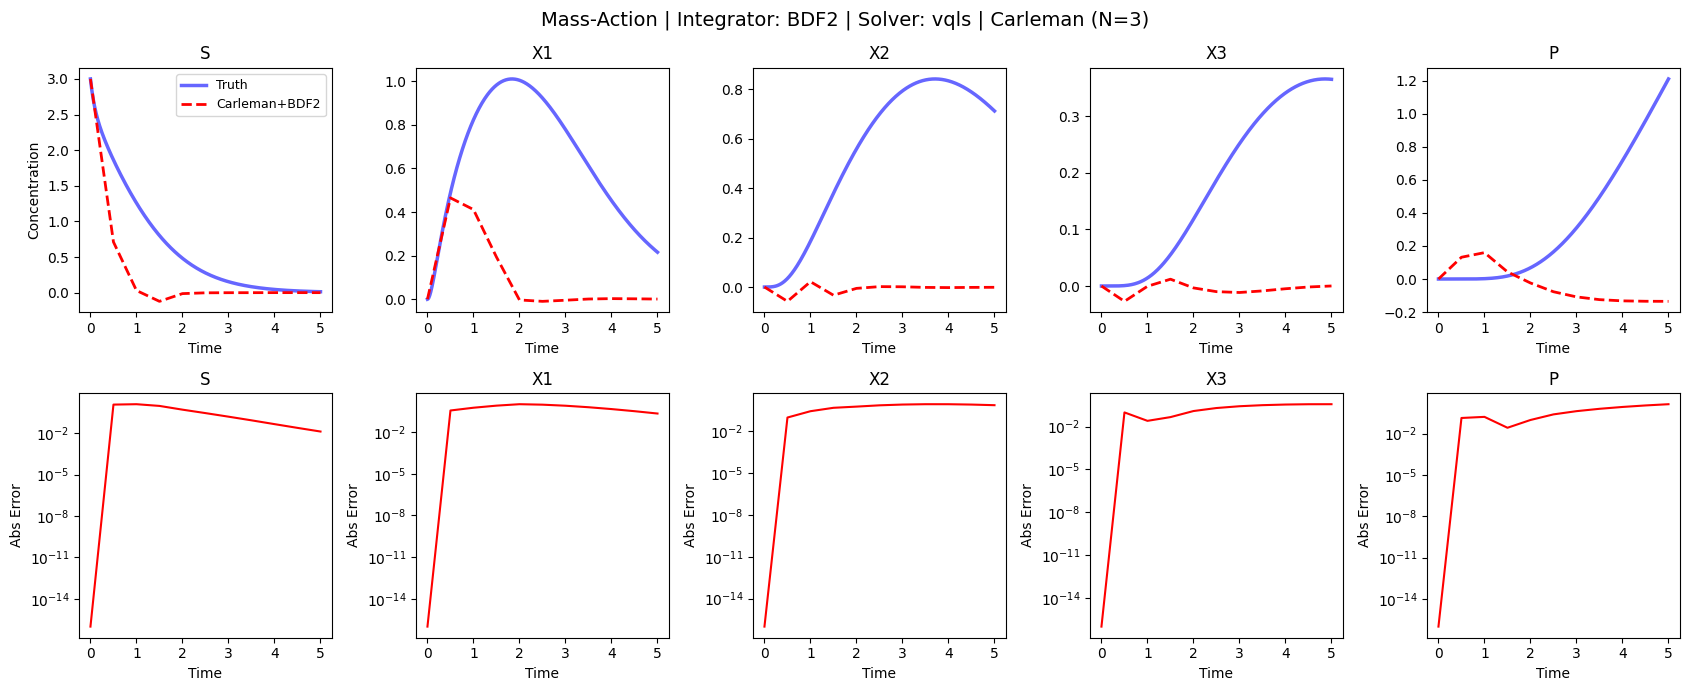


DETAILED SUMMARY

Carleman Truncation Order N=3

[Mass-Action]
  - Lifted Dimension: 219 (~8 qubits)
  - Propagator cond(M): 21.046
  - Errors per Metabolite (BDF2 vs. Classical):
    Label | RMSE       | Max AE    
    ------------------------------
    S     | 0.605859-0.013672j | 1.230827  
    X1    | 0.583509-0.036303j | 1.007442  
    X2    | 0.610256-0.015034j | 0.839960  
    X3    | 0.233385-0.000798j | 0.365235  
    P     | 0.631218-0.044500j | 1.347213  


In [101]:


# Plot
tags = {"MA": ["MA"], "QSSA": ["QSSA"], "BOTH": ["MA", "QSSA"]}[WHICH]
print(f"Integrator: {PLOT_MODE} | Running: {', '.join(tags)} | Solver: {SOLVER_TYPE}")
print(f"running...")

systems = {}
for tag in tags:
    d = get_system(tag)
    systems[tag] = d
    plot_system(d)

print("\n" + "=" * 15 + "\nDETAILED SUMMARY\n" + "=" * 15)
print(f"\nCarleman Truncation Order N={CARLEMAN_ORDER}")

for tag, d in systems.items():
    n_lift = d["A"].shape[0]
    print(f"\n[{d['title']}]")
    print(f"  - Lifted Dimension: {n_lift} (~{int(np.ceil(np.log2(n_lift)))} qubits)")
    if not np.isnan(d["cond"]):
        print(f"  - Propagator cond(M): {d['cond']:.3f}")

    print(f"  - Errors per Metabolite ({PLOT_MODE} vs. Classical):")
    print(f"    {'Label':<5} | {'RMSE':<10} | {'Max AE':<10}")
    print(f"    " + "-"*30)

    for i in range(n_metab):
        # Interpolate reference to simulation time grid
        ref_interp = np.interp(d["t_sim"], d["t_ref"], d["Y_ref"][:, i])
        diff = d["Y_sim"][:, i] - ref_interp

        rmse = np.sqrt(np.mean(diff**2))
        mae = np.max(np.abs(diff))

        print(f"    {metab_labels[i]:<5} | {rmse:<10.6f} | {mae:<10.6f}")

Notes:

hhl: solver + folded_EU takes time, of course expecially for smaller DT. I ran out of patience at DT = 0.2 after 20 minutes. solver + pennylane obviously works better as N_CLOCK increases. what is a reasonable limit?

qsvt: current implementation finds phase angles using either package pyqsp or using pennylane optimization. works on test matrices, does not on actual problem probably due to size/calculation constraints.

vqls: still troubleshooting the current implementation. it converges to zero after a little, X1 showing a little bit of accurancy but could be a mistake





